# 💳 Credit Card Customer Segmentation — Unsupervised Learning
**Practical Exam · Set C** &nbsp;|&nbsp; K-Means · Agglomerative Hierarchical · DBSCAN

**Business problem:** A large Indian private bank wants to stop treating every cardholder the same. Using ~8,950 anonymised cardholders, I engineer behavioural features and compare three clustering algorithms to find natural customer segments, then translate them into personas the Relationship Managers can act on.

**Dataset:** `CC_GENERAL.csv` — [Credit Card Dataset for Clustering (Kaggle)](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata)

| Step | Topic |
|---|---|
| 1 | Loading & Exploratory Data Analysis |
| 2 | Feature Engineering & Preprocessing |
| 3 | K-Means Clustering |
| 4 | Agglomerative Hierarchical Clustering |
| 5 | DBSCAN |
| 6 | Algorithm Comparison & Business Recommendation |
| 7 | Pipeline & Deployment (`joblib`) |

## 0. Import Libraries

In [1]:
import os, warnings, joblib, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, adjusted_rand_score)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 220)
os.makedirs('images', exist_ok=True)   # screenshots used in README.md

# 📂 Step 1: Dataset Loading & Exploratory Data Analysis

## 1.1 Load & Inspect the Dataset

In [2]:
df = pd.read_csv('../Dataset/CC_GENERAL.csv')
print('Shape of the dataset:', df.shape)

Shape of the dataset: (8950, 18)


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [4]:
df.head(10)

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12
7,C10008,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12
8,C10009,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12
9,C10010,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12


**Observation:** The dataset has 8,950 cardholders and 18 columns (17 numeric features + `CUST_ID`). Everything is numeric, so no encoding is needed. Only two columns have nulls, `CREDIT_LIMIT` and `MINIMUM_PAYMENTS`.

### Drop the identifier column

In [5]:
cust_id = df['CUST_ID'].copy()      # kept aside only so I can name customers in EDA
df = df.drop(columns='CUST_ID')
print('Shape after dropping CUST_ID:', df.shape)

Shape after dropping CUST_ID: (8950, 17)


### Missing values

In [6]:
missing = df.isnull().sum().to_frame('missing_count')
missing['missing_%'] = (missing['missing_count'] / len(df) * 100).round(2)
missing

,missing_count,missing_%
BALANCE,0,0.00
BALANCE_FREQUENCY,0,0.00
PURCHASES,0,0.00
ONEOFF_PURCHASES,0,0.00
INSTALLMENTS_PURCHASES,0,0.00
CASH_ADVANCE,0,0.00
PURCHASES_FREQUENCY,0,0.00
ONEOFF_PURCHASES_FREQUENCY,0,0.00
PURCHASES_INSTALLMENTS_FREQUENCY,0,0.00
CASH_ADVANCE_FREQUENCY,0,0.00


### Impute missing values with the column median

In [7]:
impute_cols = ['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']
imputed_counts = {c: int(df[c].isnull().sum()) for c in impute_cols}
medians = {c: float(df[c].median()) for c in impute_cols}      # reused later by predict_segment()

for c in impute_cols:
    df[c] = df[c].fillna(medians[c])

print('Values imputed :', imputed_counts)
print('Median used    :', {k: round(v, 2) for k, v in medians.items()})
print('Total missing left:', int(df.isnull().sum().sum()))

Values imputed : {'CREDIT_LIMIT': 1, 'MINIMUM_PAYMENTS': 313}
Median used    : {'CREDIT_LIMIT': 3000.0, 'MINIMUM_PAYMENTS': 312.34}
Total missing left: 0


### Duplicate rows

In [8]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


**Observation:** `CREDIT_LIMIT` had just **1** missing value and `MINIMUM_PAYMENTS` had **313** (3.5%). I filled both with the median (3,000 and 312.34). I used the median, not the mean, because these columns are heavily right-skewed and the mean would be pulled up by a few very large accounts. There are **0 duplicate rows**.

## 1.2 Univariate Analysis

In [9]:
df_eda = df.copy()
money_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS']

### Histograms of the main money columns (log-scaled x-axis)

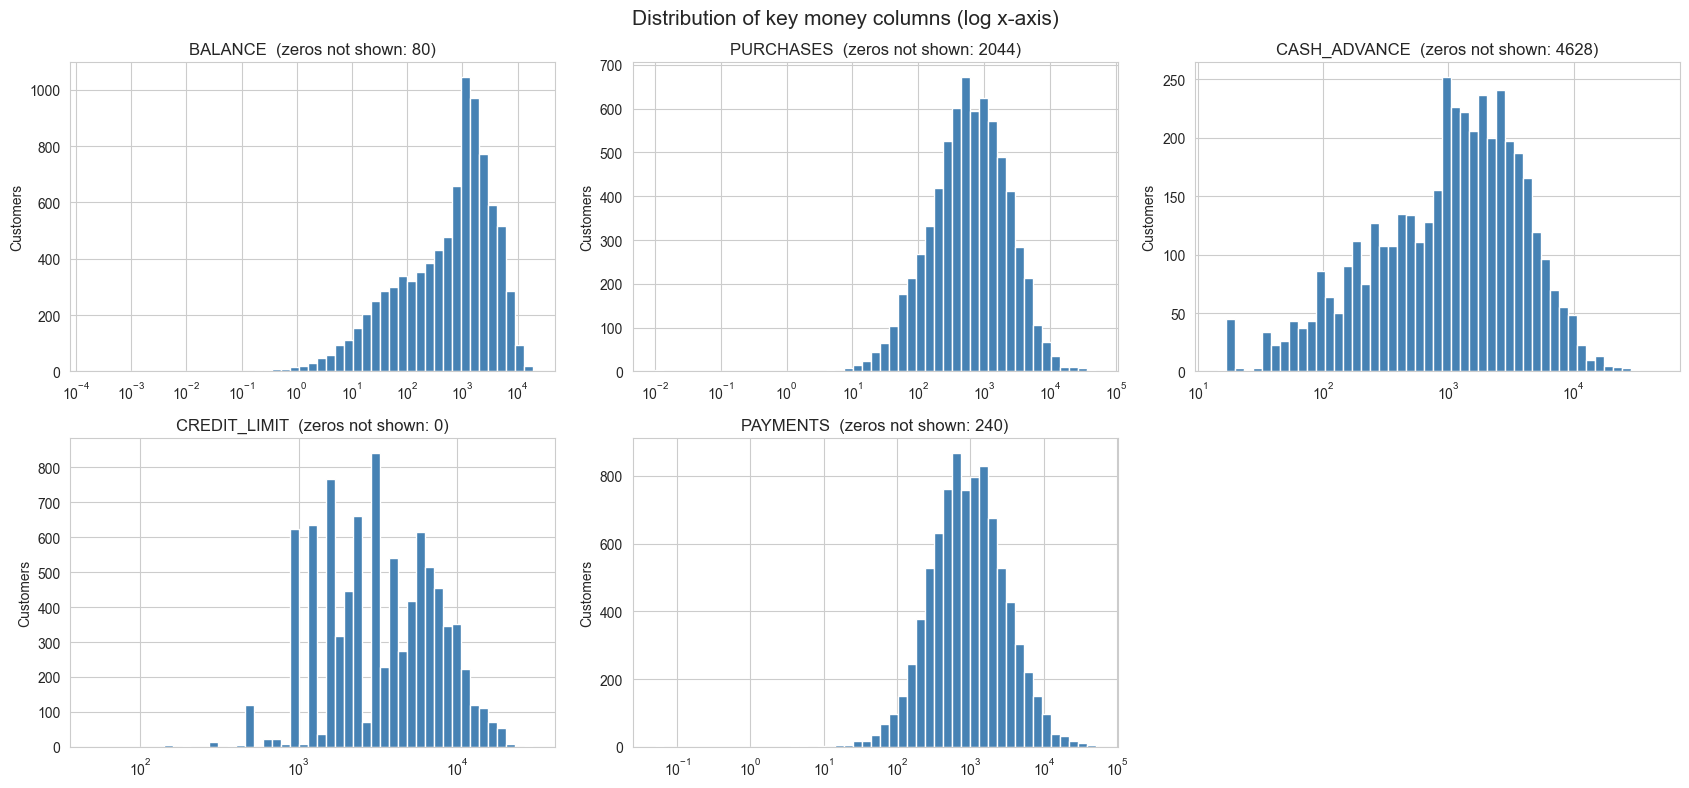

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.ravel()
for ax, c in zip(axes, money_cols):
    vals = df_eda[c][df_eda[c] > 0]                      # log axis cannot show zeros
    bins = np.logspace(np.log10(vals.min()), np.log10(vals.max()), 50)
    ax.hist(vals, bins=bins, color='steelblue', edgecolor='white')
    ax.set_xscale('log')
    ax.set_title(f'{c}  (zeros not shown: {(df_eda[c] == 0).sum()})')
    ax.set_ylabel('Customers')
axes[-1].axis('off')
plt.suptitle('Distribution of key money columns (log x-axis)', fontsize=15)
plt.tight_layout()
plt.savefig('images/01_histograms_log.png', dpi=130, bbox_inches='tight')
plt.show()

**Observation:** All five money columns are strongly right-skewed. Most customers sit in the hundreds or low thousands, while a few accounts reach tens of thousands, so the log axis was needed to see the shape. Many customers have exactly zero `PURCHASES` (2,044) or zero `CASH_ADVANCE` (4,628), which I left out of the log plots. This tells me a log transformation will be needed before clustering.

### Boxplot of TENURE

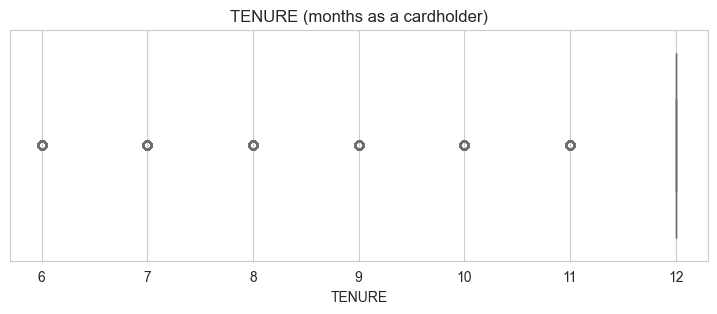

,customers
TENURE,
6,204
7,190
8,196
9,175
10,236
11,365
12,7584


In [11]:
plt.figure(figsize=(9, 3))
sns.boxplot(x=df_eda['TENURE'], color='lightcoral')
plt.title('TENURE (months as a cardholder)')
plt.savefig('images/02_tenure_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()
df_eda['TENURE'].value_counts().sort_index().to_frame('customers')

**Observation:** `TENURE` is not very informative. About **84.7%** of customers have the full 12 months, and the rest are spread between 6 and 11. The boxplot shows a median of 12 with all the shorter tenures as outliers. So tenure will not separate clusters much; behaviour will.

### Correlation heatmap (all 17 numeric features)

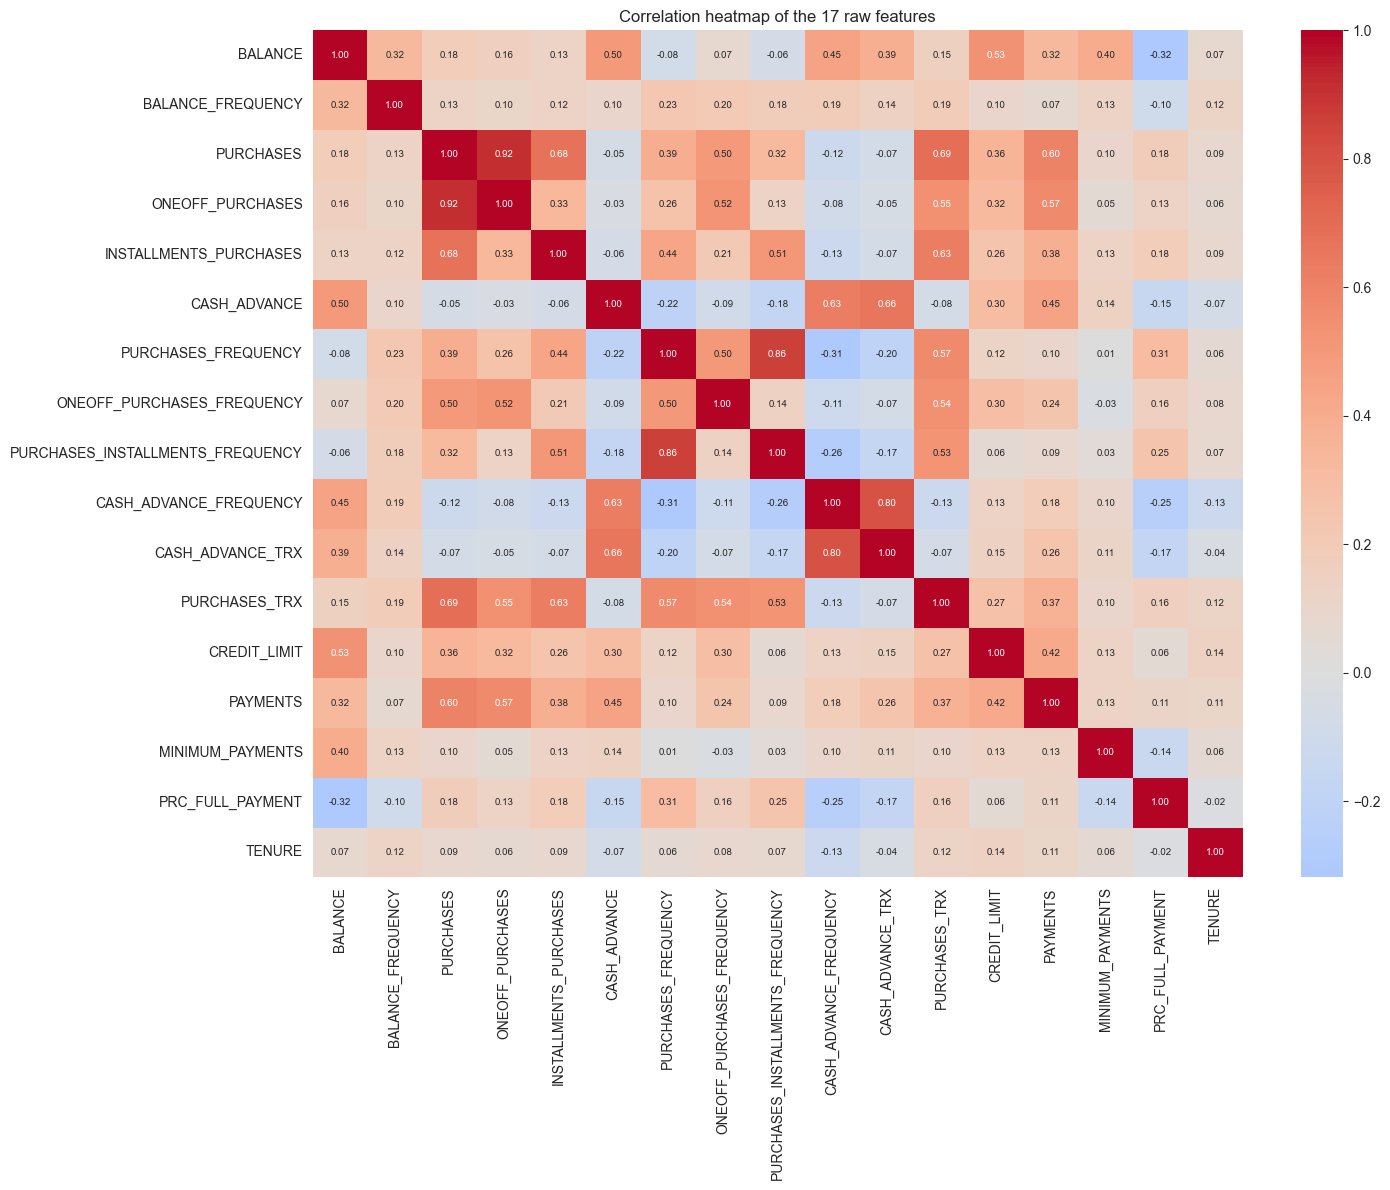

In [12]:
corr = df_eda.corr()
plt.figure(figsize=(15, 11))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size': 7})
plt.title('Correlation heatmap of the 17 raw features')
plt.savefig('images/03_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

In [13]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
high_corr = pairs[pairs.abs() >= 0.7].sort_values(ascending=False).round(3).to_frame('correlation')
high_corr

,,correlation
PURCHASES,ONEOFF_PURCHASES,0.917
PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.863
CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.800


**Observation:** Only three pairs are highly correlated: `PURCHASES` and `ONEOFF_PURCHASES` (0.92), `PURCHASES_FREQUENCY` and `PURCHASES_INSTALLMENTS_FREQUENCY` (0.86), and `CASH_ADVANCE_FREQUENCY` and `CASH_ADVANCE_TRX` (0.80). This makes sense, since one-off spend is most of total spend and more cash-advance months means more cash-advance transactions. These overlaps mean spending behaviour gets a bit more weight in distance-based clustering, which I keep in mind.

## 1.3 Customer-Level Analysis

### PURCHASES / CREDIT_LIMIT (rough utilisation)

count    8950.000
mean        0.263
std         0.437
min         0.000
25%         0.011
50%         0.117
75%         0.338
max         8.591
Name: Purchase_Utilisation, dtype: float64


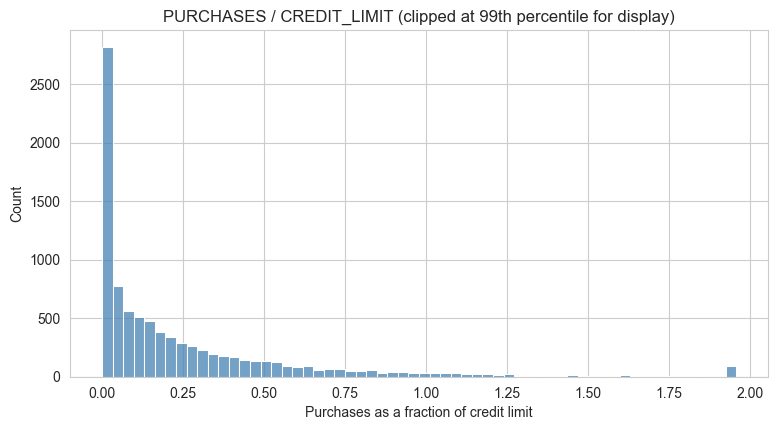

In [14]:
df_eda['Purchase_Utilisation'] = df_eda['PURCHASES'] / df_eda['CREDIT_LIMIT']
print(df_eda['Purchase_Utilisation'].describe().round(3))

plt.figure(figsize=(9, 4.5))
sns.histplot(df_eda['Purchase_Utilisation'].clip(upper=df_eda['Purchase_Utilisation'].quantile(0.99)),
             bins=60, color='steelblue', edgecolor='white')
plt.title('PURCHASES / CREDIT_LIMIT (clipped at 99th percentile for display)')
plt.xlabel('Purchases as a fraction of credit limit')
plt.savefig('images/04_purchase_utilisation.png', dpi=130, bbox_inches='tight')
plt.show()

**Observation:** The median customer uses only about 12% of their credit limit on purchases, and the mean is 26%. A few customers go above 100% (max about 8.6x) because purchases are a 12-month total while the limit is a monthly ceiling. Most cardholders are far below their limit, so there is room to offer limit increases to the right people.

### Top 10 customers by CASH_ADVANCE

In [15]:
top10_cash = (df_eda.assign(CUST_ID=cust_id)
                    .nlargest(10, 'CASH_ADVANCE')[['CUST_ID', 'CASH_ADVANCE', 'PURCHASES', 'BALANCE', 'CREDIT_LIMIT', 'PAYMENTS']])
top10_cash

,CUST_ID,CASH_ADVANCE,PURCHASES,BALANCE,CREDIT_LIMIT,PAYMENTS
2159,C12226,47137.21176,431.93,10905.053810,19600.0,39048.59762
1059,C11094,29282.10915,3719.00,8823.284205,15500.0,28150.97869
71,C10074,27296.48576,4523.27,2990.422186,7000.0,28232.69446
7254,C17450,26268.69989,1750.66,4530.205197,8500.0,25203.91336
7645,C17851,26194.04954,0.00,7081.171387,9000.0,20191.30770
2454,C12528,23130.82106,0.00,10915.550750,15000.0,18341.95467
883,C10914,22665.77850,0.00,14581.459140,18500.0,20941.32551
6371,C16546,21943.84942,0.00,4529.895962,13000.0,33486.31044
3806,C13914,20712.67008,4995.80,14100.251100,16500.0,20418.33238
6455,C16632,20277.33112,1490.75,9110.968989,11000.0,19740.74802


In [16]:
median_purchase = df_eda['PURCHASES'].median()
print('Median PURCHASES of all customers      :', round(median_purchase, 2))
print('Top-10 cash-advance customers above that:', int((top10_cash['PURCHASES'] > median_purchase).sum()), 'of 10')
print('Spearman corr (CASH_ADVANCE vs PURCHASES), all customers:',
      round(df_eda['CASH_ADVANCE'].corr(df_eda['PURCHASES'], method='spearman'), 3))

Median PURCHASES of all customers      : 361.28
Top-10 cash-advance customers above that: 6 of 10
Spearman corr (CASH_ADVANCE vs PURCHASES), all customers: -0.385


**Observation:** The top-10 cash-advance customers withdraw between about 20k and 47k. Only 6 of the 10 have purchases above the overall median, and 4 have almost no purchases at all. Across all customers the Spearman correlation between `CASH_ADVANCE` and `PURCHASES` is **-0.39**, so heavy cash-advance users are mostly a **distinct group** and not the same people as the big spenders.

### Customers who never made a purchase

In [17]:
never_purchase_pct = (df_eda['PURCHASES'] == 0).mean() * 100
print(f'Customers with PURCHASES == 0: {(df_eda["PURCHASES"] == 0).sum()}  ({never_purchase_pct:.2f}%)')

Customers with PURCHASES == 0: 2044  (22.84%)


**Observation:** **22.84%** of customers (2,044) never made a purchase. They only use the card for cash advances or just keep a balance. This is a big dormant/non-spending block that the bank earns little interchange from.

### 📌 Pareto check — what % of customers drive 80% of PURCHASES?

2346 customers (26.2% of all cardholders) generate 80% of total PURCHASES


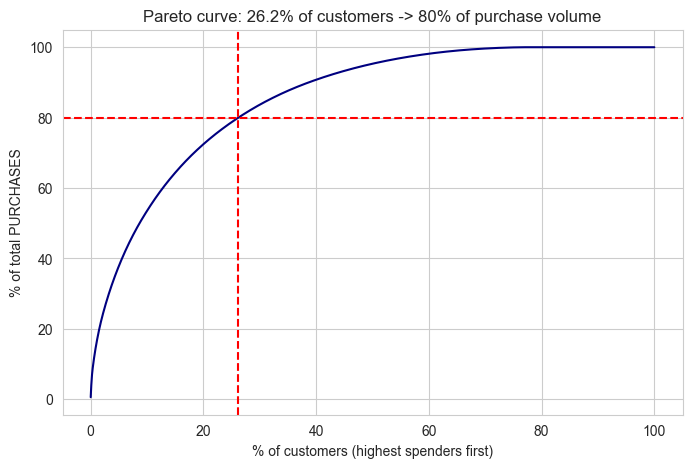

In [18]:
sorted_p = df_eda['PURCHASES'].sort_values(ascending=False).reset_index(drop=True)
cum_share = sorted_p.cumsum() / sorted_p.sum()
n80 = int((cum_share < 0.80).sum() + 1)
pct80 = n80 / len(sorted_p) * 100
print(f'{n80} customers ({pct80:.1f}% of all cardholders) generate 80% of total PURCHASES')

x = np.arange(1, len(sorted_p) + 1) / len(sorted_p) * 100
plt.figure(figsize=(8, 5))
plt.plot(x, cum_share * 100, color='navy')
plt.axhline(80, color='red', ls='--'); plt.axvline(pct80, color='red', ls='--')
plt.xlabel('% of customers (highest spenders first)'); plt.ylabel('% of total PURCHASES')
plt.title(f'Pareto curve: {pct80:.1f}% of customers -> 80% of purchase volume')
plt.savefig('images/05_pareto_curve.png', dpi=130, bbox_inches='tight')
plt.show()

**Observation:** The Pareto principle is confirmed, roughly. **26.2%** of customers (2,346) generate 80% of the total purchase volume. It is not exactly 80/20 but it is very concentrated, so the top spenders are worth protecting.

# 🔧 Step 2: Feature Engineering & Preprocessing

## 2.1 Engineer Behavioural Features

In [19]:
df_model = df.copy()

df_model['Monthly_Avg_Purchase']         = df_model['PURCHASES'] / df_model['TENURE']
df_model['Monthly_Avg_Cash_Advance']     = df_model['CASH_ADVANCE'] / df_model['TENURE']
# guard against divide-by-zero: a zero credit limit gives NaN -> 0
df_model['Limit_Usage']                  = (df_model['BALANCE'] / df_model['CREDIT_LIMIT'].replace(0, np.nan)).fillna(0)
df_model['Payment_to_Minpayment_Ratio']  = df_model['PAYMENTS'] / (df_model['MINIMUM_PAYMENTS'] + 1)

new_features = ['Monthly_Avg_Purchase', 'Monthly_Avg_Cash_Advance', 'Limit_Usage', 'Payment_to_Minpayment_Ratio']
df_feat = df_model.copy()    # raw + engineered, UNSCALED: cluster labels are attached here later
print('Feature-engineered DataFrame shape:', df_feat.shape, '(one row per cardholder)')

Feature-engineered DataFrame shape: (8950, 21) (one row per cardholder)


In [20]:
df_feat.head(10)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,7.950000,0.000000,0.040901,1.436214
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0.000000,536.912124,0.457495,3.822677
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,64.430833,0.000000,0.332687,0.990103
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,124.916667,17.149001,0.222223,0.000000
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1.333333,0.000000,0.681429,2.759800
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,111.106667,0.000000,1.005460,0.581360
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12,590.917500,0.000000,0.046464,31.920658
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,36.350000,0.000000,0.792892,1.273962
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,71.790833,0.000000,0.144989,2.199230
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,106.800000,0.000000,0.013839,11.497972


In [21]:
df_feat[new_features].describe().round(3)

,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
count,8950.000,8950.000,8950.000,8950.000
mean,86.175,88.978,0.389,6.391
std,180.509,193.136,0.390,31.995
min,0.000,0.000,0.000,0.000
25%,3.399,0.000,0.041,0.911
50%,31.937,0.000,0.303,2.017
75%,97.228,99.085,0.718,6.014
max,4086.631,3928.101,15.910,1863.850


In [22]:
new_feat_summary = pd.DataFrame({
    'min': df_feat[new_features].min(),
    'max': df_feat[new_features].max(),
    'range': df_feat[new_features].max() - df_feat[new_features].min(),
    'skewness': df_feat[new_features].skew()
}).round(3)
new_feat_summary

,min,max,range,skewness
Monthly_Avg_Purchase,0.0,4086.631,4086.631,8.005
Monthly_Avg_Cash_Advance,0.0,3928.101,3928.101,4.944
Limit_Usage,0.0,15.910,15.910,7.417
Payment_to_Minpayment_Ratio,0.0,1863.850,1863.850,36.902


**Observation:** The engineered features are all right-skewed. `Payment_to_Minpayment_Ratio` is by far the worst (skew about 36.9, range 0 to 1,864) because `MINIMUM_PAYMENTS` can be small. `Monthly_Avg_Purchase` (skew 8.0) and `Limit_Usage` (skew 7.4) also have long tails, and `Monthly_Avg_Cash_Advance` has skew 4.9. All four need outlier handling and a log transform.

## 2.2 Handle Outliers

### Boxplots BEFORE capping

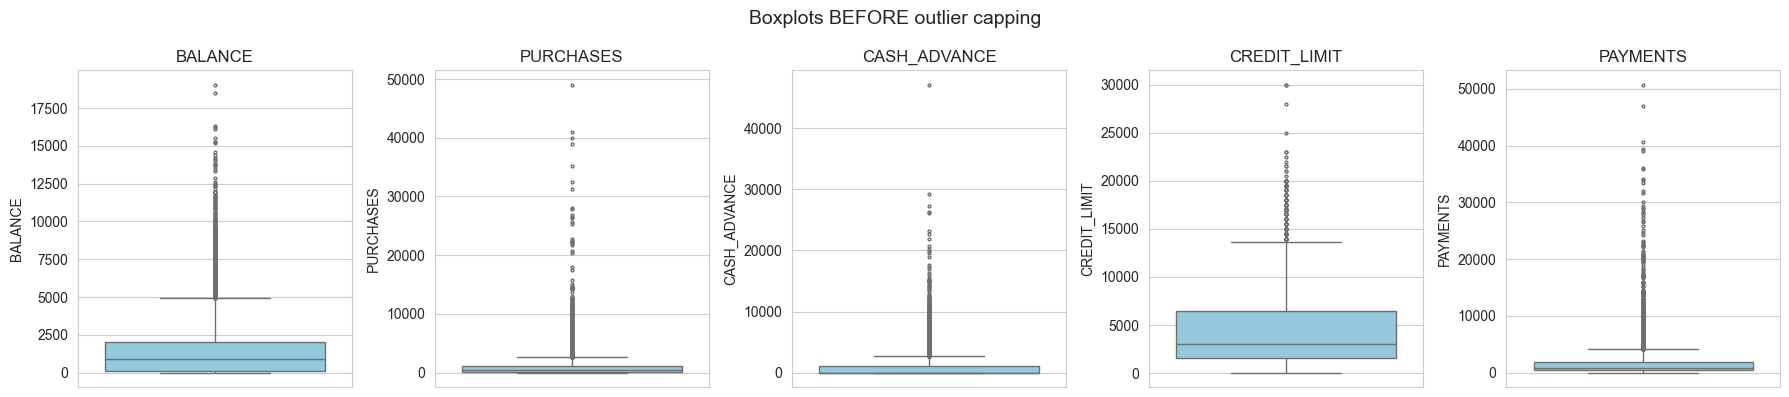

In [23]:
def boxplot_grid(data, title, fname):
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    for ax, c in zip(axes, money_cols):
        sns.boxplot(y=data[c], ax=ax, color='skyblue', flierprops={'markersize': 2})
        ax.set_title(c)
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()

boxplot_grid(df_model, 'Boxplots BEFORE outlier capping', 'images/06_boxplots_before.png')

### Outlier table (IQR rule, upper fence = Q3 + 3 × IQR)

In [24]:
cap_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE',
            'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS'] + new_features

cap_thresholds = {}
rows = []
for c in cap_cols:
    q1, q3 = df_model[c].quantile([0.25, 0.75])
    upper = q3 + 3 * (q3 - q1)
    cap_thresholds[c] = float(upper)
    rows.append([c, q1, q3, upper, df_model[c].max(), int((df_model[c] > upper).sum())])

outlier_table = pd.DataFrame(rows, columns=['column', 'Q1', 'Q3', 'cap (Q3+3*IQR)', 'max', 'extreme_outliers']).set_index('column').round(2)
outlier_table

,Q1,Q3,cap (Q3+3*IQR),max,extreme_outliers
column,,,,,
BALANCE,128.28,2054.14,7831.71,19043.14,194
PURCHASES,39.64,1110.13,4321.62,49039.57,391
ONEOFF_PURCHASES,0.00,577.40,2309.62,40761.25,566
INSTALLMENTS_PURCHASES,0.00,468.64,1874.55,22500.00,395
CASH_ADVANCE,0.00,1113.82,4455.28,47137.21,486
CREDIT_LIMIT,1600.00,6500.00,21200.00,30000.00,10
PAYMENTS,383.28,1901.13,6454.71,50721.48,402
MINIMUM_PAYMENTS,170.86,788.71,2642.28,76406.21,470
Monthly_Avg_Purchase,3.40,97.23,378.72,4086.63,363


### Cap (winsorise) the extreme outliers — no rows are dropped

In [25]:
for c in cap_cols:
    df_model[c] = df_model[c].clip(upper=cap_thresholds[c])

print('Rows before/after capping:', len(df), '/', len(df_model))

Rows before/after capping: 8950 / 8950


### Boxplots AFTER capping

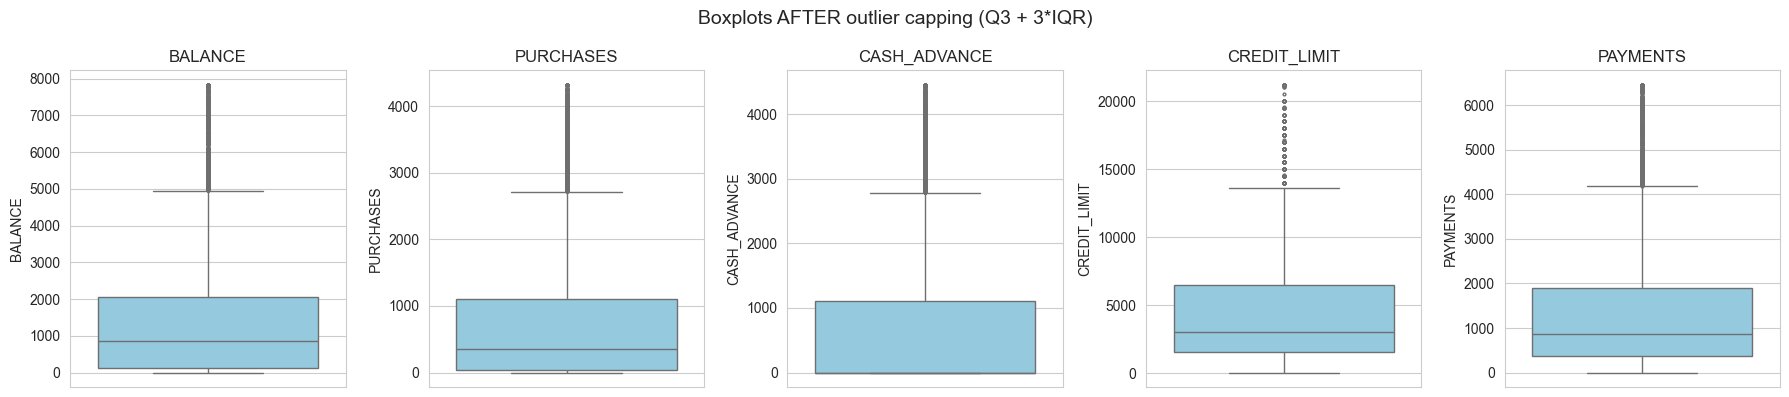

In [26]:
boxplot_grid(df_model, 'Boxplots AFTER outlier capping (Q3 + 3*IQR)', 'images/07_boxplots_after.png')

**Observation:** Extreme outliers (above Q3 + 3xIQR) exist in every money column. For example, 391 customers have very high `PURCHASES`, 486 have high `CASH_ADVANCE`, and 194 have very high `BALANCE`. The max `PURCHASES` was 49,040 but the cap is only 4,322. I capped 12 columns (raw money columns and engineered features) without dropping any rows. After capping, the boxplots are compressed and the whiskers are readable, so outliers are handled.

## 2.3 Transform Skewed Features

### Histograms BEFORE log transformation

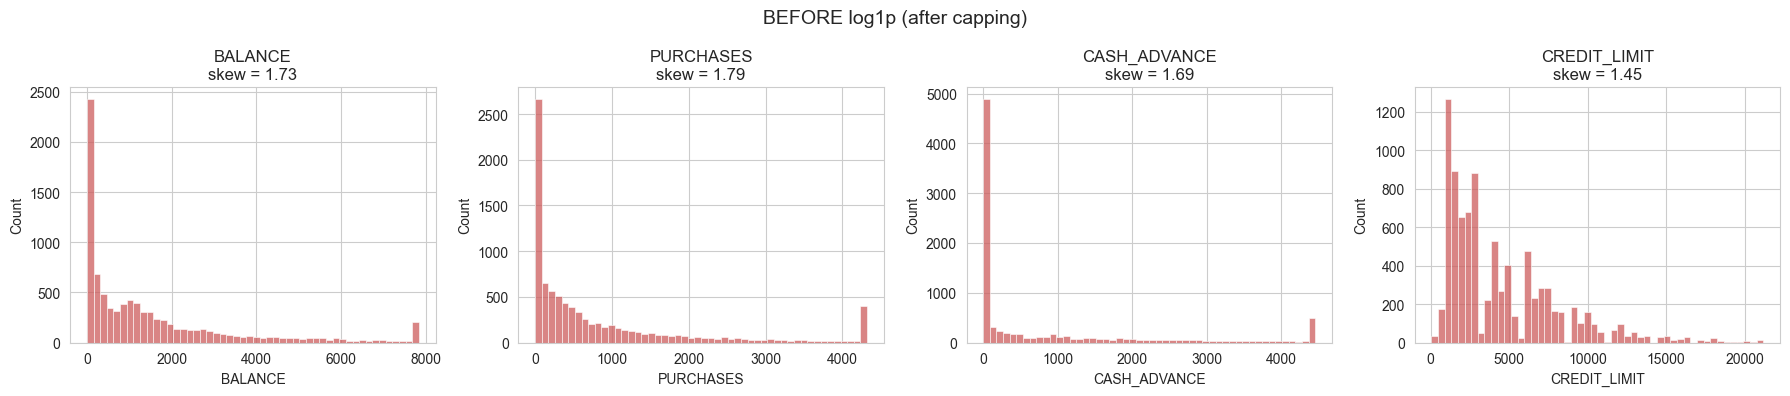

In [27]:
skew_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT']
skew_before = df_model[cap_cols].skew()

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, skew_cols):
    sns.histplot(df_model[c], bins=50, ax=ax, color='indianred')
    ax.set_title(f'{c}\nskew = {skew_before[c]:.2f}')
plt.suptitle('BEFORE log1p (after capping)', fontsize=14)
plt.tight_layout()
plt.savefig('images/08_hist_before_log.png', dpi=130, bbox_inches='tight')
plt.show()

### Apply log1p to all monetary columns

In [28]:
df_model[cap_cols] = np.log1p(df_model[cap_cols])
skew_after = df_model[cap_cols].skew()

### Histograms AFTER log transformation

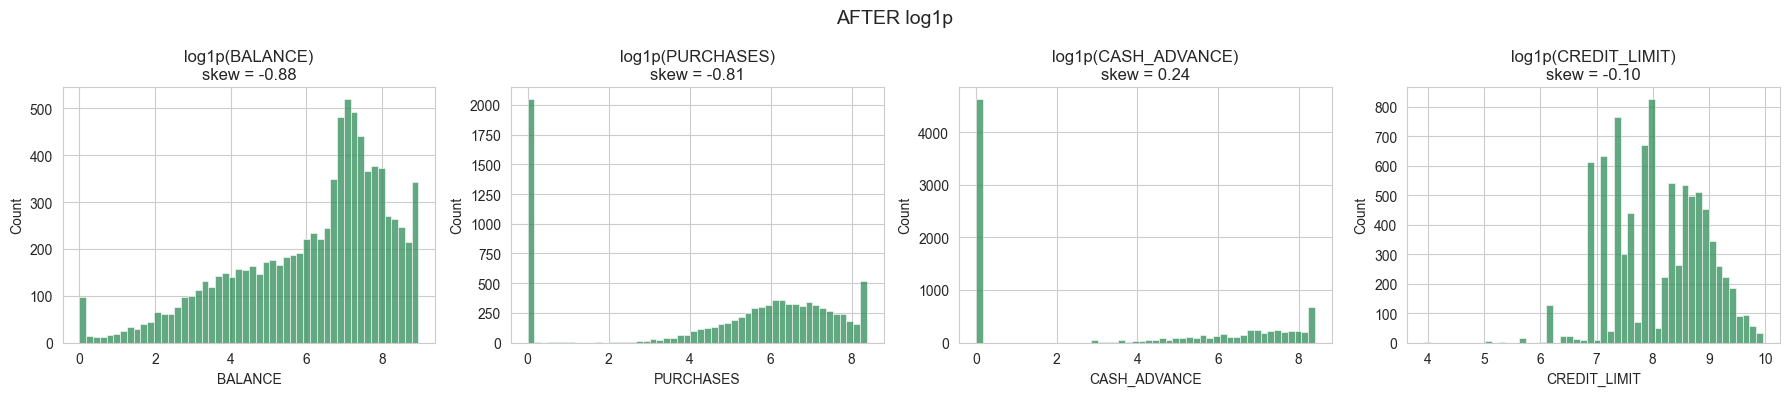

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, c in zip(axes, skew_cols):
    sns.histplot(df_model[c], bins=50, ax=ax, color='seagreen')
    ax.set_title(f'log1p({c})\nskew = {skew_after[c]:.2f}')
plt.suptitle('AFTER log1p', fontsize=14)
plt.tight_layout()
plt.savefig('images/09_hist_after_log.png', dpi=130, bbox_inches='tight')
plt.show()

In [30]:
skew_table = pd.DataFrame({'skew_before': skew_before, 'skew_after_log1p': skew_after}).round(2)
skew_table

,skew_before,skew_after_log1p
BALANCE,1.73,-0.88
PURCHASES,1.79,-0.81
ONEOFF_PURCHASES,1.71,0.14
INSTALLMENTS_PURCHASES,1.76,-0.05
CASH_ADVANCE,1.69,0.24
CREDIT_LIMIT,1.45,-0.10
PAYMENTS,1.73,-1.98
MINIMUM_PAYMENTS,1.72,-0.15
Monthly_Avg_Purchase,1.80,-0.41
Monthly_Avg_Cash_Advance,1.69,0.40


**Observation:** Before the log transform, the skew was about 1.5 to 1.8 for the money columns. After `log1p`, most values moved close to zero (for example `CASH_ADVANCE` 0.24 and `CREDIT_LIMIT` -0.10), so the distributions are much more symmetrical. `PAYMENTS` became slightly left-skewed (-1.98) because of the small values, but it is still better than before.

## 2.4 Scale the Features

In [31]:
feature_cols = list(df_model.columns)            # 17 raw + 4 engineered = 21 features
scaler = StandardScaler()
cc_scaled = pd.DataFrame(scaler.fit_transform(df_model), columns=feature_cols, index=df_model.index)
X = cc_scaled.values                              # numpy array used by every algorithm
print('cc_scaled shape:', cc_scaled.shape)

cc_scaled shape: (8950, 21)


In [32]:
scaled_check = pd.DataFrame({'mean': cc_scaled.mean(), 'std': cc_scaled.std(ddof=0)}).round(4)
scaled_check.T

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Monthly_Avg_Purchase,Monthly_Avg_Cash_Advance,Limit_Usage,Payment_to_Minpayment_Ratio
mean,0.0,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### Optional PCA (used only to report dimensionality and to draw a 2-D map)

In [33]:
pca_90 = PCA(n_components=0.90, random_state=42).fit(X)
pca_95 = PCA(n_components=0.95, random_state=42).fit(X)
print('Components to keep 90% variance:', pca_90.n_components_)
print('Components to keep 95% variance:', pca_95.n_components_)

Components to keep 90% variance: 9
Components to keep 95% variance: 12


**Observation:** After `StandardScaler` every feature has mean 0 and std 1, so scaling worked. There are 21 features (17 raw + 4 engineered). PCA needs **9 components for 90%** variance and 12 for 95%. I did not cluster on PCA, I used the full scaled data, because it keeps the features interpretable and makes `predict_segment()` simpler.

# 🔵 Step 3: K-Means Clustering

## 3.1 Elbow Method & Silhouette — find optimal k

In [34]:
k_range = range(2, 11)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X, km.labels_))

kmeans_k_table = pd.DataFrame({'k': list(k_range), 'Inertia (WCSS)': inertias, 'Silhouette': sil_scores}).set_index('k')
kmeans_k_table['Inertia drop %'] = (kmeans_k_table['Inertia (WCSS)'].pct_change() * -100).round(2)
kmeans_k_table.round(4)

,Inertia (WCSS),Silhouette,Inertia drop %
k,,,
2,142834.5137,0.2367,NaN
3,122733.9940,0.2114,14.07
4,111216.0785,0.1975,9.38
5,102155.6337,0.1937,8.15
6,94656.0673,0.1986,7.34
7,90369.9806,0.1972,4.53
8,86651.3311,0.1935,4.11
9,83239.5116,0.1756,3.94
10,80040.5206,0.1845,3.84


k with the highest Silhouette: 2


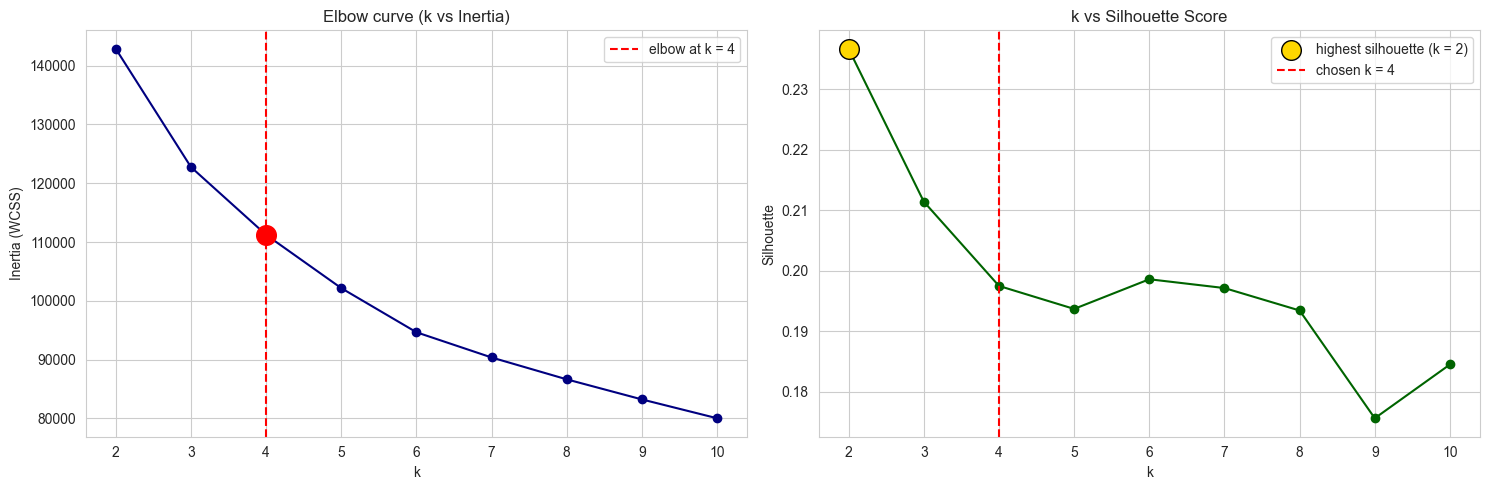

In [35]:
k_optimal = 4      # chosen after looking at both curves (justified below)
k_best_sil = int(kmeans_k_table['Silhouette'].idxmax())
print('k with the highest Silhouette:', k_best_sil)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(list(k_range), inertias, 'o-', color='navy')
ax[0].axvline(k_optimal, color='red', ls='--', label=f'elbow at k = {k_optimal}')
ax[0].scatter([k_optimal], [inertias[k_optimal - 2]], s=200, color='red', zorder=5)
ax[0].set_title('Elbow curve (k vs Inertia)'); ax[0].set_xlabel('k'); ax[0].set_ylabel('Inertia (WCSS)'); ax[0].legend()

ax[1].plot(list(k_range), sil_scores, 'o-', color='darkgreen')
ax[1].scatter([k_best_sil], [max(sil_scores)], s=200, color='gold', edgecolor='k', zorder=5, label=f'highest silhouette (k = {k_best_sil})')
ax[1].axvline(k_optimal, color='red', ls='--', label=f'chosen k = {k_optimal}')
ax[1].set_title('k vs Silhouette Score'); ax[1].set_xlabel('k'); ax[1].set_ylabel('Silhouette'); ax[1].legend()
plt.tight_layout()
plt.savefig('images/10_kmeans_elbow_silhouette.png', dpi=130, bbox_inches='tight')
plt.show()

**Justification for k = 4:** The Silhouette score is highest at k = 2 (0.237), but two clusters is too coarse for a bank, it would just split active vs inactive customers. The elbow curve bends around k = 4, where the drop in inertia falls under 10% per extra cluster, and the Silhouette only falls from 0.211 (k=3) to 0.198 (k=4), so we lose very little quality. k = 4 also gives four clear and different personas that the business can act on, so I chose **k = 4**.

## 3.2 Train the final K-Means model

In [36]:
kmeans_final = KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=42).fit(X)
df_feat['KMeans_Cluster'] = kmeans_final.labels_
df_feat['KMeans_Cluster'].value_counts().sort_index().to_frame('customers')

,customers
KMeans_Cluster,
0,2429
1,2514
2,2359
3,1648


## 3.3 Visualise the K-Means clusters

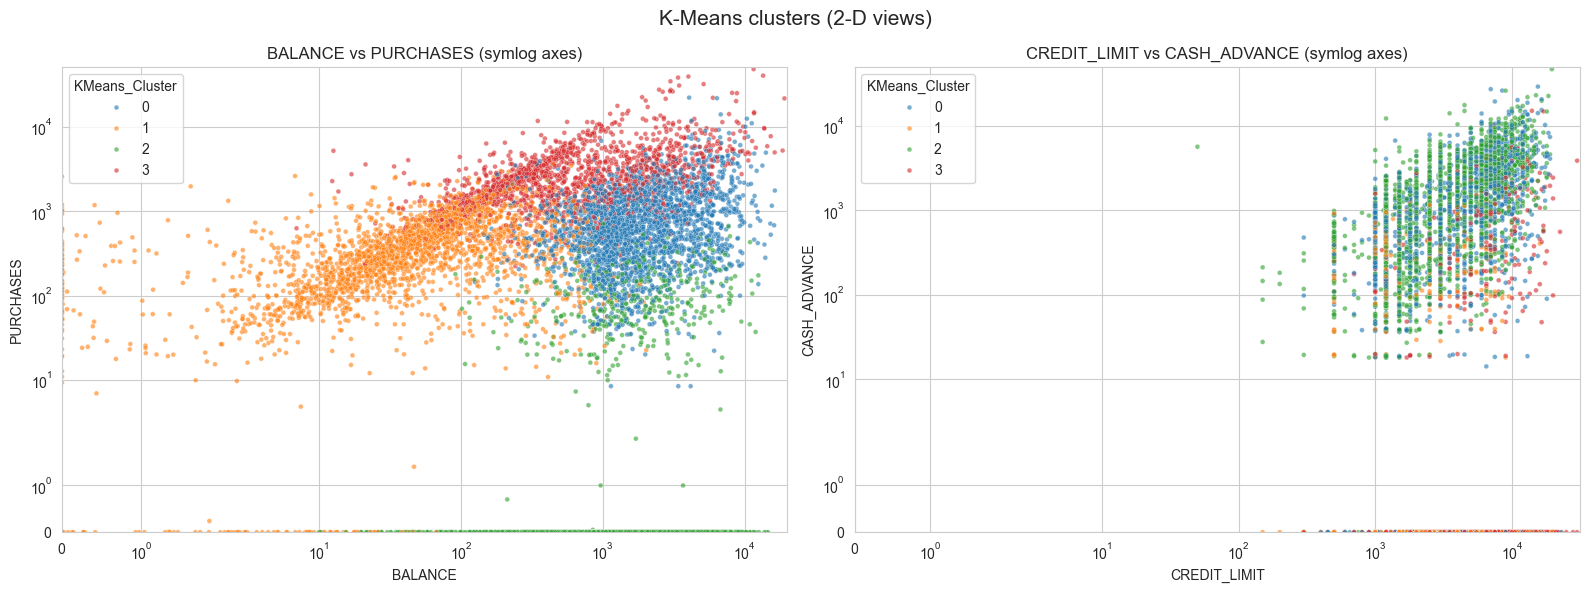

In [37]:
def cluster_palette(labels):
    ids = sorted(set(labels) - {-1})
    pal = dict(zip(ids, sns.color_palette('tab10', len(ids))))
    if -1 in set(labels):
        pal[-1] = (0.7, 0.7, 0.7)
    return pal

pal_km = cluster_palette(df_feat['KMeans_Cluster'])

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=df_feat, x='BALANCE', y='PURCHASES', hue='KMeans_Cluster', palette=pal_km, s=12, alpha=0.6, ax=ax[0])
ax[0].set_xscale('symlog'); ax[0].set_yscale('symlog'); ax[0].set_xlim(left=0); ax[0].set_ylim(bottom=0); ax[0].set_title('BALANCE vs PURCHASES (symlog axes)')
sns.scatterplot(data=df_feat, x='CREDIT_LIMIT', y='CASH_ADVANCE', hue='KMeans_Cluster', palette=pal_km, s=12, alpha=0.6, ax=ax[1])
ax[1].set_xscale('symlog'); ax[1].set_yscale('symlog'); ax[1].set_xlim(left=0); ax[1].set_ylim(bottom=0); ax[1].set_title('CREDIT_LIMIT vs CASH_ADVANCE (symlog axes)')
plt.suptitle('K-Means clusters (2-D views)', fontsize=15)
plt.tight_layout()
plt.savefig('images/11_kmeans_2d.png', dpi=130, bbox_inches='tight')
plt.show()

### 3-D scatter: BALANCE vs PURCHASES vs CASH_ADVANCE (log1p axes so the shape is readable)

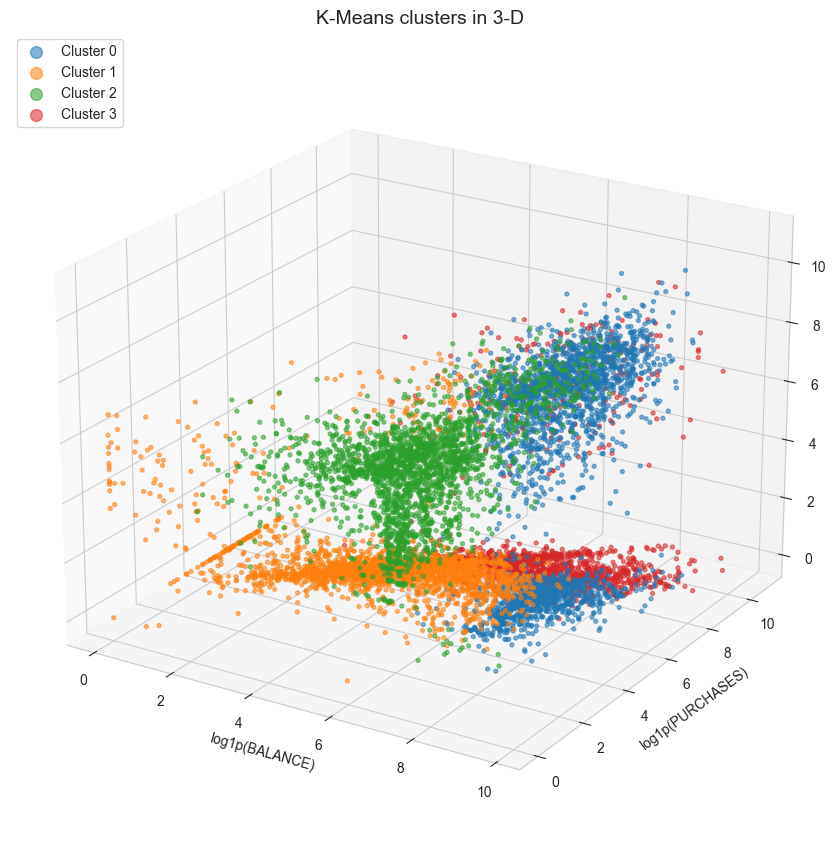

In [38]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')
for cl in sorted(df_feat['KMeans_Cluster'].unique()):
    sub = df_feat[df_feat['KMeans_Cluster'] == cl]
    ax.scatter(np.log1p(sub['BALANCE']), np.log1p(sub['PURCHASES']), np.log1p(sub['CASH_ADVANCE']),
               s=8, alpha=0.55, color=pal_km[cl], label=f'Cluster {cl}')
ax.set_xlabel('log1p(BALANCE)'); ax.set_ylabel('log1p(PURCHASES)'); ax.set_zlabel('log1p(CASH_ADVANCE)', labelpad=8)
ax.set_title('K-Means clusters in 3-D', fontsize=14)
ax.view_init(elev=22, azim=-58)
ax.legend(markerscale=3, loc='upper left')
fig.subplots_adjust(left=0.0, right=0.86, bottom=0.03, top=0.94)
plt.savefig('images/12_kmeans_3d.png', dpi=130)
plt.show()

In [39]:
# interactive version (open the saved HTML file in a browser and rotate it)
fig3d = px.scatter_3d(df_feat.assign(cluster=df_feat['KMeans_Cluster'].astype(str),
                                     BALANCE_log=np.log1p(df_feat['BALANCE']),
                                     PURCHASES_log=np.log1p(df_feat['PURCHASES']),
                                     CASH_ADVANCE_log=np.log1p(df_feat['CASH_ADVANCE'])),
                      x='BALANCE_log', y='PURCHASES_log', z='CASH_ADVANCE_log', color='cluster',
                      opacity=0.6, title='K-Means clusters (interactive 3-D, log1p axes)')
fig3d.update_traces(marker=dict(size=2.5))
fig3d.write_html('images/kmeans_3d_interactive.html')
print('Saved interactive plot -> images/kmeans_3d_interactive.html')

Saved interactive plot -> images/kmeans_3d_interactive.html


**Observation:** In the BALANCE vs PURCHASES plot, one cluster sits at high purchases with a moderate balance, and another sits at almost zero purchases with a high balance. The other two overlap more in the middle. The 3-D plot shows the same thing, with the cash-advance group rising along the CASH_ADVANCE axis. The clusters touch each other, which fits with the low Silhouette (about 0.2): behaviour is a continuum, not clear-cut islands.

## 3.4 Profile the K-Means clusters (original, unscaled values)

In [40]:
profile_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'TENURE']
km_profile = df_feat.groupby('KMeans_Cluster')[profile_cols].mean()
km_profile['Customers'] = df_feat['KMeans_Cluster'].value_counts()
km_profile['Share_%'] = (km_profile['Customers'] / len(df_feat) * 100).round(1)
km_profile.sort_values('CREDIT_LIMIT', ascending=False).round(2)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,Customers,Share_%
KMeans_Cluster,,,,,,,,
3,1313.24,3284.35,191.20,6785.83,3244.76,11.87,1648,18.4
0,2546.30,995.86,1340.27,4336.95,1786.64,11.61,2429,27.1
2,2275.92,21.63,2160.54,4174.34,1744.54,11.36,2359,26.4
1,112.95,436.00,37.22,3444.34,679.85,11.35,2514,28.1


In [41]:
# extra behavioural columns that help me name the clusters
extra_cols = ['PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT', 'Limit_Usage', 'Payment_to_Minpayment_Ratio']
df_feat.groupby('KMeans_Cluster')[extra_cols].mean().round(3)

,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,Limit_Usage,Payment_to_Minpayment_Ratio
KMeans_Cluster,,,,,
0,0.613,0.181,0.019,0.665,2.183
1,0.536,0.010,0.285,0.050,9.273
2,0.025,0.295,0.033,0.598,4.403
3,0.908,0.030,0.325,0.201,11.042


In [42]:
# median profile as a robustness check (means are pulled up by a few very large accounts)
df_feat.groupby('KMeans_Cluster')[profile_cols].median().round(2)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE
KMeans_Cluster,,,,,,
0,1701.20,622.03,365.49,3000.0,1017.24,12.0
1,42.59,310.35,0.00,2500.0,386.45,12.0
2,1541.74,0.00,1364.85,3000.0,802.04,12.0
3,539.37,2275.22,0.00,6000.0,2096.64,12.0


### Assign business personas (rule-based, so the labels stay correct even if cluster ids change)

In [43]:
tr = km_profile['PURCHASES'].idxmax()                    # highest spend
ca = km_profile['PURCHASES'].idxmin()                  # (almost) no purchases but heavy cash advance
rest = [c for c in km_profile.index if c not in (tr, ca)]
rv = km_profile.loc[rest, 'BALANCE'].idxmax()            # big balance, moderate spend
la = km_profile.loc[rest, 'BALANCE'].idxmin()            # small balance
km_personas = {tr: 'Premium Transactors', ca: 'Cash-Advance Reliant', rv: 'Revolvers', la: 'Low-Activity Light Users'}
assert len(km_personas) == k_optimal, 'two rules picked the same cluster - check the profile'

df_feat['KMeans_Persona'] = df_feat['KMeans_Cluster'].map(km_personas)
km_persona_table = km_profile.assign(Persona=pd.Series(km_personas)).sort_values('CREDIT_LIMIT', ascending=False)
km_persona_table[['Persona'] + list(km_profile.columns)].round(2)

,Persona,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,Customers,Share_%
KMeans_Cluster,,,,,,,,,
3,Premium Transactors,1313.24,3284.35,191.20,6785.83,3244.76,11.87,1648,18.4
0,Revolvers,2546.30,995.86,1340.27,4336.95,1786.64,11.61,2429,27.1
2,Cash-Advance Reliant,2275.92,21.63,2160.54,4174.34,1744.54,11.36,2359,26.4
1,Low-Activity Light Users,112.95,436.00,37.22,3444.34,679.85,11.35,2514,28.1


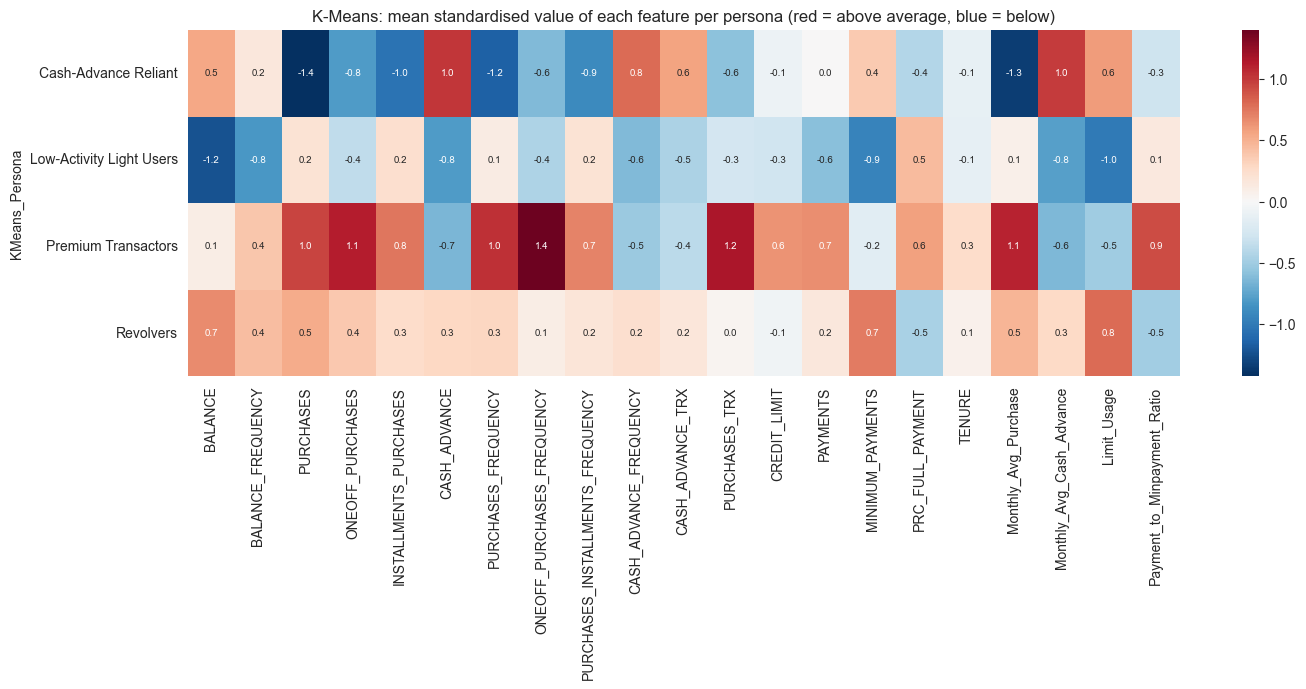

In [44]:
# standardised profile heatmap: which features define each cluster?
z_profile = cc_scaled.groupby(df_feat['KMeans_Persona']).mean()
plt.figure(figsize=(16, 4.5))
sns.heatmap(z_profile, cmap='RdBu_r', center=0, annot=True, fmt='.1f', annot_kws={'size': 7})
plt.title('K-Means: mean standardised value of each feature per persona (red = above average, blue = below)')
plt.savefig('images/13_kmeans_profile_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

**Observation and persona justification (K-Means, k = 4):**

| Cluster | Persona | Why (from the profile) |
|---|---|---|
| 3 | **Premium Transactors** | Highest `PURCHASES` (3,284) and highest `CREDIT_LIMIT` (6,786), buys in about 91% of months, uses only 20% of the limit, and 32% of the time pays in full. They spend a lot and repay, so they earn interchange but little interest. |
| 0 | **Revolvers** | High `BALANCE` (2,546) with 67% limit usage, moderate purchases (996) and some cash advance (1,340). Their payments are only about 2.2x the minimum and they pay in full just 1.9% of the time, so they carry debt and generate the most interest income. |
| 2 | **Cash-Advance Reliant** | Almost no purchases (22) but the highest `CASH_ADVANCE` (2,161) and a high balance (2,276). They use the card as a loan, drawing cash in about 30% of months. This is a higher credit-risk group. |
| 1 | **Low-Activity Light Users** | Tiny balance (113), only 5% limit usage and low payments (680). The card is barely used, which makes them the most likely to become dormant or churn. |

The median table gives the same story, so the means are not just driven by a few big accounts.

# 🌳 Step 4: Agglomerative Hierarchical Clustering

## 4.1 Dendrogram Analysis

In [45]:
Z = linkage(X, method='ward')
print('Linkage matrix shape:', Z.shape)

Linkage matrix shape: (8949, 4)


In [46]:
heights = Z[:, 2]
cut_rows = []
for n in [3, 4, 5]:
    lo, hi = heights[-n], heights[-(n - 1)]       # any cut in [lo, hi) yields exactly n clusters
    cut_rows.append([n, round(lo, 1), round(hi, 1), round((lo + hi) / 2, 1)])
cut_table = pd.DataFrame(cut_rows, columns=['clusters', 'cut_from', 'cut_to', 'mid_cut']).set_index('clusters')
cut_table

,cut_from,cut_to,mid_cut
clusters,,,
3,157.0,164.3,160.7
4,124.4,157.0,140.7
5,111.1,124.4,117.7


Chosen cut distance = 140.7 -> 4 clusters


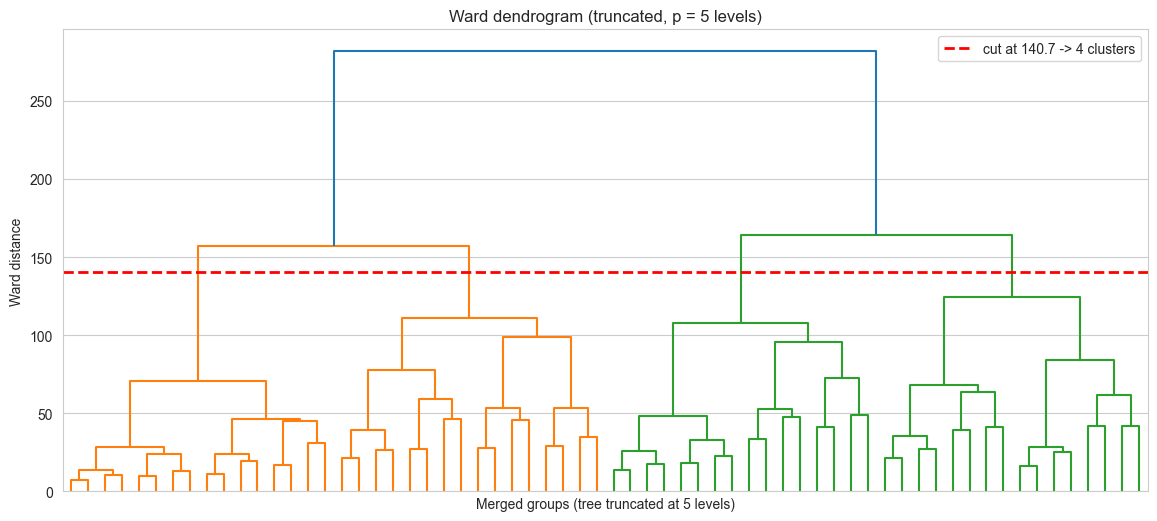

In [47]:
n_chosen = 4
cut_distance = float(cut_table.loc[n_chosen, 'mid_cut'])
check = len(set(fcluster(Z, t=cut_distance, criterion='distance')))
print(f'Chosen cut distance = {cut_distance} -> {check} clusters')

plt.figure(figsize=(14, 6))
dendrogram(Z, truncate_mode='level', p=5, show_leaf_counts=True, no_labels=True)
plt.axhline(cut_distance, color='red', ls='--', lw=2, label=f'cut at {cut_distance} -> {n_chosen} clusters')
plt.title('Ward dendrogram (truncated, p = 5 levels)')
plt.xlabel('Merged groups (tree truncated at 5 levels)'); plt.ylabel('Ward distance')
plt.legend()
plt.savefig('images/14_dendrogram.png', dpi=130, bbox_inches='tight')
plt.show()

**Observation:** The last merges of the Ward tree happen at distances of about 282, 164, 157, 124 and 111. A cut between **124 and 157** gives 4 clusters, between 157 and 164 gives 3, and between 111 and 124 gives 5. The gap from 124 to 157 is wide, so 4 clusters is a stable cut. I chose the middle, **distance 140.7 -> 4 clusters**, which also matches K-Means so the two can be compared fairly.

## 4.2 Train Agglomerative models & compare linkage methods

In [48]:
def evaluate_labels(labels, data):
    return silhouette_score(data, labels), davies_bouldin_score(data, labels), calinski_harabasz_score(data, labels)

link_rows, link_labels = [], {}
for link in ['ward', 'complete', 'average']:
    lab = AgglomerativeClustering(n_clusters=n_chosen, linkage=link).fit_predict(X)
    link_labels[link] = lab
    sil, dbi, chi = evaluate_labels(lab, X)
    sizes = np.bincount(lab)
    link_rows.append([link, sil, dbi, chi, sizes.tolist(), sizes.min() / len(lab) * 100])

linkage_table = pd.DataFrame(link_rows, columns=['linkage', 'Silhouette', 'Davies-Bouldin', 'Calinski-Harabasz', 'cluster_sizes', 'smallest_cluster_%']).set_index('linkage')
linkage_table.round(3)

,Silhouette,Davies-Bouldin,Calinski-Harabasz,cluster_sizes,smallest_cluster_%
linkage,,,,,
ward,0.142,1.999,1594.940,"[2533, 2403, 2406, 1608]",17.966
complete,0.086,1.793,417.641,"[6763, 38, 57, 2092]",0.425
average,0.390,0.699,85.637,"[8898, 45, 1, 6]",0.011


In [49]:
# rule: best Silhouette among linkages that do NOT create tiny throw-away clusters (smallest cluster >= 5% of customers)
eligible = linkage_table[linkage_table['smallest_cluster_%'] >= 5]
best_link = eligible['Silhouette'].idxmax()
print('Best linkage:', best_link)

agg_final = AgglomerativeClustering(n_clusters=n_chosen, linkage=best_link).fit(X)
df_feat['Agg_Cluster'] = agg_final.labels_
df_feat['Agg_Cluster'].value_counts().sort_index().to_frame('customers')

Best linkage: ward


,customers
Agg_Cluster,
0,2533
1,2403
2,2406
3,1608


**Observation:** Ward gives four balanced clusters (2,533 / 2,403 / 2,406 / 1,608) with Silhouette 0.142. Complete linkage gives unequal clusters (6,763 / 38 / 57 / 2,092). Average linkage has the highest Silhouette (0.390) but it is misleading: it puts 8,898 customers in one cluster and makes tiny clusters of 45, 6 and even **1** customer, so it just isolates outliers. This matches the note in the exam: Ward is compact and even like K-Means, complete is uneven, average is in between and chains. I picked **Ward** as the best usable linkage (best Silhouette among linkages whose smallest cluster is at least 5% of customers).

## 4.3 Visualise & profile the hierarchical clusters

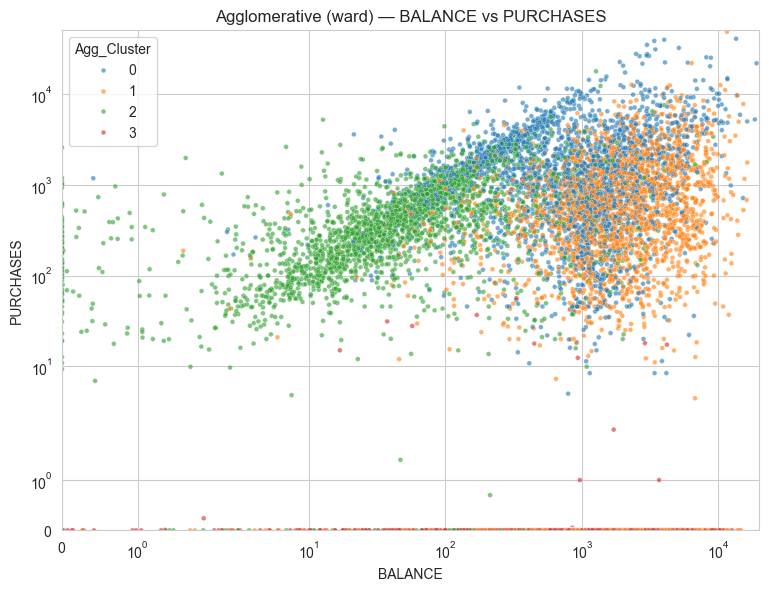

In [50]:
pal_ag = cluster_palette(df_feat['Agg_Cluster'])
plt.figure(figsize=(9, 6.5))
sns.scatterplot(data=df_feat, x='BALANCE', y='PURCHASES', hue='Agg_Cluster', palette=pal_ag, s=12, alpha=0.6)
plt.xscale('symlog'); plt.yscale('symlog'); plt.xlim(left=0); plt.ylim(bottom=0)
plt.title(f'Agglomerative ({best_link}) — BALANCE vs PURCHASES')
plt.savefig('images/15_agg_2d.png', dpi=130, bbox_inches='tight')
plt.show()

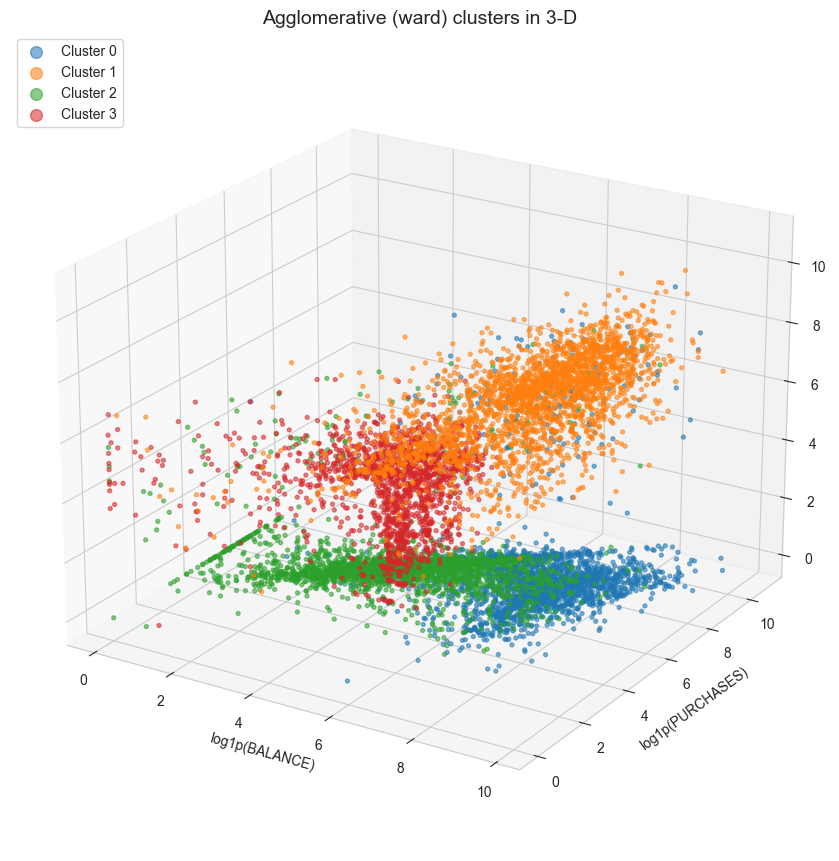

In [51]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')
for cl in sorted(df_feat['Agg_Cluster'].unique()):
    sub = df_feat[df_feat['Agg_Cluster'] == cl]
    ax.scatter(np.log1p(sub['BALANCE']), np.log1p(sub['PURCHASES']), np.log1p(sub['CASH_ADVANCE']),
               s=8, alpha=0.55, color=pal_ag[cl], label=f'Cluster {cl}')
ax.set_xlabel('log1p(BALANCE)'); ax.set_ylabel('log1p(PURCHASES)'); ax.set_zlabel('log1p(CASH_ADVANCE)', labelpad=8)
ax.set_title(f'Agglomerative ({best_link}) clusters in 3-D', fontsize=14)
ax.view_init(elev=22, azim=-58); ax.legend(markerscale=3, loc='upper left')
fig.subplots_adjust(left=0.0, right=0.86, bottom=0.03, top=0.94)
plt.savefig('images/16_agg_3d.png', dpi=130)
plt.show()

In [52]:
ag_profile = df_feat.groupby('Agg_Cluster')[profile_cols].mean()
ag_profile['Customers'] = df_feat['Agg_Cluster'].value_counts()
ag_profile['Share_%'] = (ag_profile['Customers'] / len(df_feat) * 100).round(1)
ag_profile.sort_values('CREDIT_LIMIT', ascending=False).round(2)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,Customers,Share_%
Agg_Cluster,,,,,,,,
0,1438.57,2128.58,69.12,5210.54,2150.01,11.95,2533,28.3
1,2778.47,916.88,2462.68,5055.15,2388.51,11.11,2403,26.8
3,1978.62,0.17,1546.53,3811.58,1564.19,11.82,1608,18.0
2,207.76,575.00,75.30,3636.31,752.64,11.27,2406,26.9


In [53]:
df_feat.groupby('Agg_Cluster')[extra_cols].mean().round(3)

,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,Limit_Usage,Payment_to_Minpayment_Ratio
Agg_Cluster,,,,,
0,0.733,0.012,0.187,0.388,6.624
1,0.470,0.331,0.042,0.578,4.134
2,0.582,0.010,0.303,0.071,7.154
3,0.001,0.225,0.044,0.585,8.252


In [54]:
tr = ag_profile['PURCHASES'].idxmax()
ca = ag_profile['PURCHASES'].idxmin()
rest = [c for c in ag_profile.index if c not in (tr, ca)]
rv = ag_profile.loc[rest, 'BALANCE'].idxmax()
la = ag_profile.loc[rest, 'BALANCE'].idxmin()
ag_personas = {tr: 'Premium Transactors', ca: 'Cash-Advance Reliant', rv: 'Revolvers', la: 'Low-Activity Light Users'}
assert len(ag_personas) == n_chosen

df_feat['Agg_Persona'] = df_feat['Agg_Cluster'].map(ag_personas)
ag_persona_table = ag_profile.assign(Persona=pd.Series(ag_personas)).sort_values('CREDIT_LIMIT', ascending=False)
ag_persona_table[['Persona'] + list(ag_profile.columns)].round(2)

,Persona,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,Customers,Share_%
Agg_Cluster,,,,,,,,,
0,Premium Transactors,1438.57,2128.58,69.12,5210.54,2150.01,11.95,2533,28.3
1,Revolvers,2778.47,916.88,2462.68,5055.15,2388.51,11.11,2403,26.8
3,Cash-Advance Reliant,1978.62,0.17,1546.53,3811.58,1564.19,11.82,1608,18.0
2,Low-Activity Light Users,207.76,575.00,75.30,3636.31,752.64,11.27,2406,26.9


### Do Hierarchical clusters match K-Means clusters?

In [55]:
km_vs_ag = pd.crosstab(df_feat['KMeans_Persona'], df_feat['Agg_Persona'], margins=True)
print('Adjusted Rand Index (K-Means vs Agglomerative):', round(adjusted_rand_score(df_feat['KMeans_Cluster'], df_feat['Agg_Cluster']), 3))
print('Customers given the same persona by both methods: {:.1f}%'.format((df_feat['KMeans_Persona'] == df_feat['Agg_Persona']).mean() * 100))
km_vs_ag

Adjusted Rand Index (K-Means vs Agglomerative): 0.438
Customers given the same persona by both methods: 70.8%


Agg_Persona,Cash-Advance Reliant,Low-Activity Light Users,Premium Transactors,Revolvers,All
KMeans_Persona,,,,,
Cash-Advance Reliant,1546,62,14,737,2359
Low-Activity Light Users,62,2070,281,101,2514
Premium Transactors,0,183,1312,153,1648
Revolvers,0,91,926,1412,2429
All,1608,2406,2533,2403,8950


**Observation:** The two methods agree on **about 71%** of customers (Adjusted Rand Index 0.44). The biggest disagreement is the K-Means **Revolvers** group: 1,412 of them stay Revolvers in the hierarchical result but 926 are pushed into Transactors, because the hierarchical Transactor cluster is wider and reaches into moderate spenders. Also 737 of K-Means' Cash-Advance Reliant customers become Revolvers in the hierarchical result, since they have high balances and some purchases. Both methods find the same four types, they just draw the boundaries in different places.

# 🔴 Step 5: DBSCAN Clustering

## 5.1 Tune epsilon with the k-NN distance plot

In [56]:
min_pts = 5
nn = NearestNeighbors(n_neighbors=min_pts).fit(X)
distances, _ = nn.kneighbors(X)
knn_dist = np.sort(distances[:, -1])          # 5th column = distance to the (MinPts-1)=4th real neighbour (col 0 is the point itself)

# knee = point furthest from the straight line joining the first and last point of the curve
xn = np.linspace(0, 1, len(knn_dist))
yn = (knn_dist - knn_dist.min()) / (knn_dist.max() - knn_dist.min())
knee_idx = int(np.argmax(xn - yn))
knee_eps = float(knn_dist[knee_idx])
print('Knee position: point #', knee_idx, 'of', len(knn_dist), '-> eps ~', round(knee_eps, 2))
print('Percentiles of the k-NN distance:', {p: round(float(np.percentile(knn_dist, p)), 2) for p in [50, 90, 95, 99]})

Knee position: point # 8482 of 8950 -> eps ~ 2.42
Percentiles of the k-NN distance: {50: 1.24, 90: 2.12, 95: 2.45, 99: 3.33}


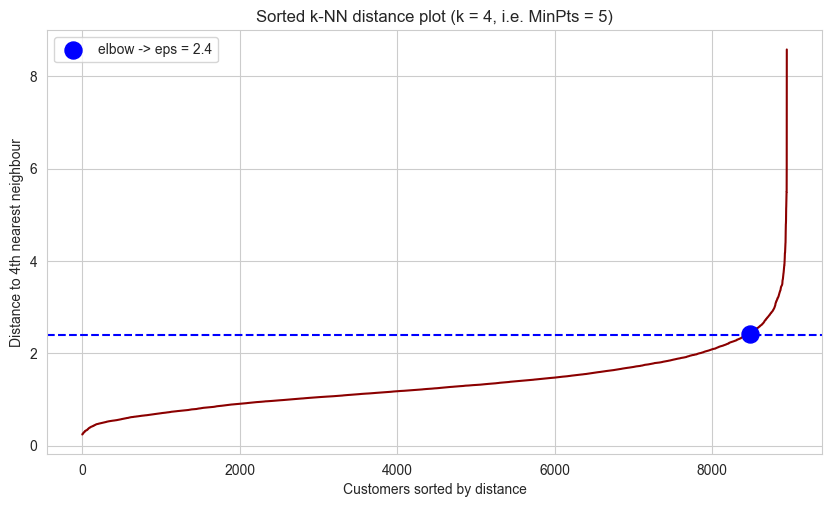

In [57]:
eps_optimal = round(knee_eps, 1)
plt.figure(figsize=(10, 5.5))
plt.plot(knn_dist, color='darkred')
plt.scatter([knee_idx], [knn_dist[knee_idx]], s=150, color='blue', zorder=5, label=f'elbow -> eps = {eps_optimal}')
plt.axhline(eps_optimal, color='blue', ls='--')
plt.title('Sorted k-NN distance plot (k = 4, i.e. MinPts = 5)')
plt.xlabel('Customers sorted by distance'); plt.ylabel('Distance to 4th nearest neighbour')
plt.legend()
plt.savefig('images/17_knn_distance.png', dpi=130, bbox_inches='tight')
plt.show()

**Observation:** The sorted 4-NN distance curve is flat at about 1.2 for the median customer, rises slowly, then shoots up in the last few percent (95th percentile 2.45, 99th percentile 3.33). The elbow found by the furthest-point-from-the-line method is at about **eps = 2.4**. I chose this because below it most customers still have close neighbours, and above it the distance to neighbours rises sharply, which means those are isolated points.

## 5.2 Train DBSCAN with the elbow epsilon

In [58]:
db_first = DBSCAN(eps=eps_optimal, min_samples=5, metric='euclidean').fit(X)
lab = db_first.labels_
n_cl = len(set(lab)) - (1 if -1 in lab else 0)
print(f'eps = {eps_optimal}, min_samples = 5')
print('(a) clusters found (excluding noise):', n_cl)
print('(b) noise points                    :', int((lab == -1).sum()))
print(f'(c) % of customers flagged as noise : {(lab == -1).mean() * 100:.2f}%')
print('Cluster sizes:', pd.Series(lab).value_counts().to_dict())

eps = 2.4, min_samples = 5
(a) clusters found (excluding noise): 2
(b) noise points                    : 241
(c) % of customers flagged as noise : 2.69%
Cluster sizes: {0: 8707, -1: 241, 1: 2}


**Observation:** With eps = 2.4 and min_samples = 5, DBSCAN finds only **2 clusters** (one huge with 8,707 customers and one with 2 customers) and **241 noise points (2.69%)**. So it basically sees one big dense blob, because behavioural data forms a continuum with no gaps in the middle.

## 5.3 Tune DBSCAN hyper-parameters (grid search)

In [59]:
eps_grid = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5, 3.0]      # first five = exam grid, last three = extra values I added
ms_grid = [3, 5, 8, 10]

grid_rows = []
for eps in eps_grid:
    for ms in ms_grid:
        lab = DBSCAN(eps=eps, min_samples=ms).fit_predict(X)
        mask = lab != -1
        n_cl = len(set(lab[mask]))
        sil = silhouette_score(X[mask], lab[mask]) if n_cl >= 2 else np.nan     # silhouette on NON-noise points only
        grid_rows.append([eps, ms, n_cl, int((~mask).sum()), (~mask).mean() * 100, sil])

dbscan_grid = pd.DataFrame(grid_rows, columns=['eps', 'min_samples', 'clusters', 'noise_points', 'noise_%', 'silhouette'])
dbscan_grid.round(3)

,eps,min_samples,clusters,noise_points,noise_%,silhouette
0,0.3,3,26,8807,98.402,0.414
1,0.3,5,5,8894,99.374,0.403
2,0.3,8,1,8935,99.832,NaN
3,0.3,10,0,8950,100.000,NaN
4,0.5,3,87,8142,90.972,0.110
5,0.5,5,27,8502,94.994,0.199
6,0.5,8,4,8715,97.374,0.404
7,0.5,10,1,8776,98.056,NaN
8,0.7,3,151,6926,77.385,-0.061
9,0.7,5,38,7517,83.989,-0.042


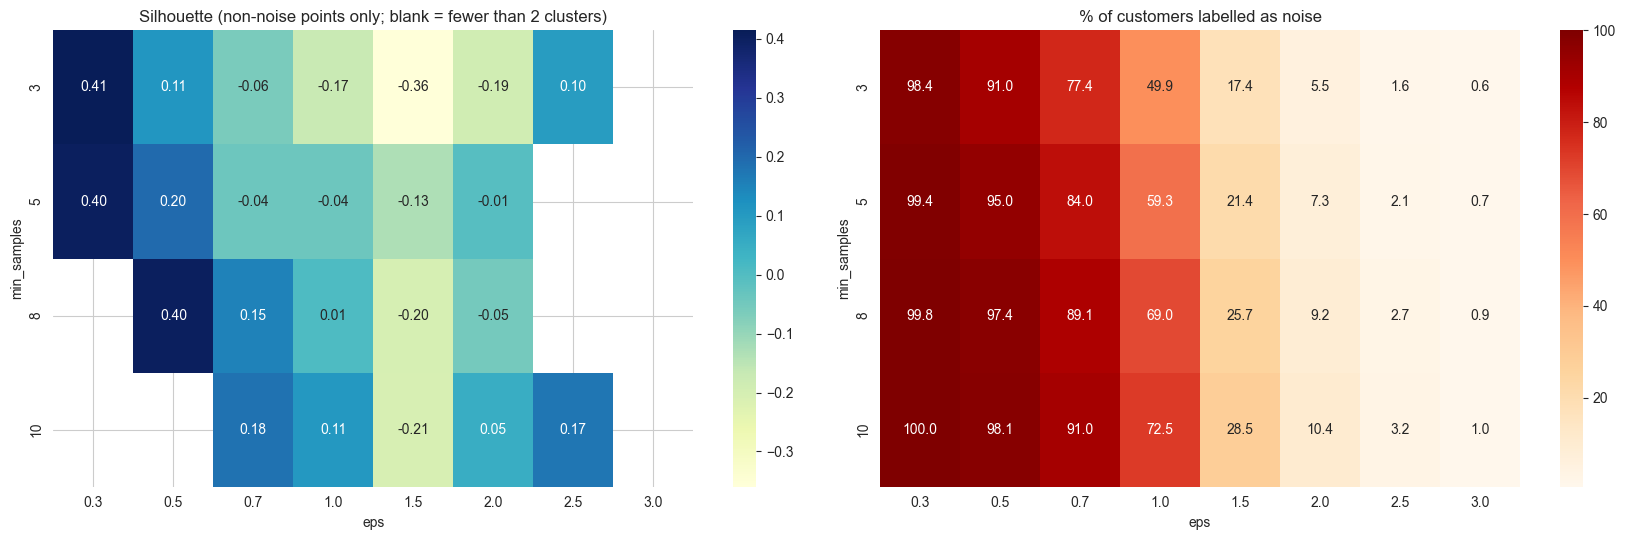

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(17, 5.5))
sns.heatmap(dbscan_grid.pivot(index='min_samples', columns='eps', values='silhouette'), annot=True, fmt='.2f', cmap='YlGnBu', ax=ax[0])
ax[0].set_title('Silhouette (non-noise points only; blank = fewer than 2 clusters)')
sns.heatmap(dbscan_grid.pivot(index='min_samples', columns='eps', values='noise_%'), annot=True, fmt='.1f', cmap='OrRd', ax=ax[1])
ax[1].set_title('% of customers labelled as noise')
plt.tight_layout()
plt.savefig('images/18_dbscan_grid_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

### Select the best combination

In [61]:
# A silhouette on non-noise points can look great when almost everything is thrown away as noise,
# so I only accept combinations with >= 2 clusters and <= 15% noise.
valid = dbscan_grid[(dbscan_grid['clusters'] >= 2) & (dbscan_grid['noise_%'] <= 15)].dropna(subset=['silhouette'])
best_row = valid.sort_values('silhouette', ascending=False).iloc[0]
best_eps, best_ms = float(best_row['eps']), int(best_row['min_samples'])
print('Best combination -> eps =', best_eps, ', min_samples =', best_ms)
valid.sort_values('silhouette', ascending=False).head(5).round(3)

Best combination -> eps = 2.5 , min_samples = 10


,eps,min_samples,clusters,noise_points,noise_%,silhouette
27,2.5,10,2,284,3.173,0.174
24,2.5,3,5,144,1.609,0.097
23,2.0,10,5,930,10.391,0.049
21,2.0,5,9,654,7.307,-0.007
22,2.0,8,6,821,9.173,-0.053


In [62]:
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_ms, metric='euclidean').fit(X)
df_feat['DBSCAN_Cluster'] = dbscan_final.labels_
db_summary = df_feat['DBSCAN_Cluster'].value_counts().sort_index().to_frame('customers')
db_summary['share_%'] = (db_summary['customers'] / len(df_feat) * 100).round(2)
db_summary

,customers,share_%
DBSCAN_Cluster,,
-1,284,3.17
0,8651,96.66
1,15,0.17


**Observation:** The exam grid (eps 0.3 to 1.5) mostly gives 20% to 99% noise, because in 21 dimensions the points are far apart, so I added eps = 2.0, 2.5 and 3.0. Small eps values give a high Silhouette (0.40 or so) only because 98% to 99% of customers are thrown away as noise, which is not useful. Large eps values (3.0) merge everything into 1 cluster. I only accepted combinations with at least 2 clusters and at most 15% noise, and the best is **eps = 2.5, min_samples = 10** (Silhouette 0.174, 3.17% noise): a main cluster of 8,651 customers, a small cluster of 15 and 284 noise points.

## 5.4 Visualise & profile the DBSCAN clusters

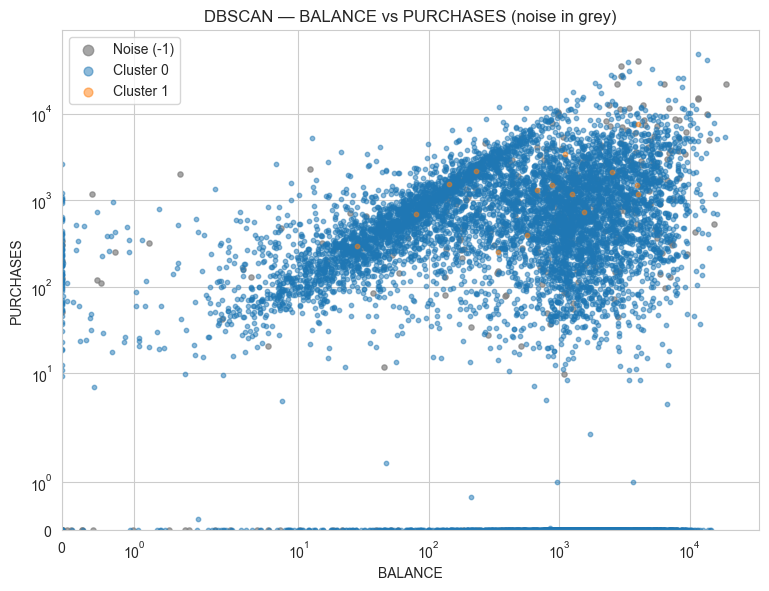

In [63]:
pal_db = cluster_palette(df_feat['DBSCAN_Cluster'])
noise = df_feat[df_feat['DBSCAN_Cluster'] == -1]
core = df_feat[df_feat['DBSCAN_Cluster'] != -1]

plt.figure(figsize=(9, 6.5))
plt.scatter(noise['BALANCE'], noise['PURCHASES'], s=14, color='grey', alpha=0.7, label='Noise (-1)')
for cl in sorted(core['DBSCAN_Cluster'].unique()):
    sub = core[core['DBSCAN_Cluster'] == cl]
    plt.scatter(sub['BALANCE'], sub['PURCHASES'], s=10, alpha=0.5, color=pal_db[cl], label=f'Cluster {cl}')
plt.xscale('symlog'); plt.yscale('symlog'); plt.xlim(left=0); plt.ylim(bottom=0)
plt.xlabel('BALANCE'); plt.ylabel('PURCHASES'); plt.title('DBSCAN — BALANCE vs PURCHASES (noise in grey)')
plt.legend(markerscale=2)
plt.savefig('images/19_dbscan_2d.png', dpi=130, bbox_inches='tight')
plt.show()

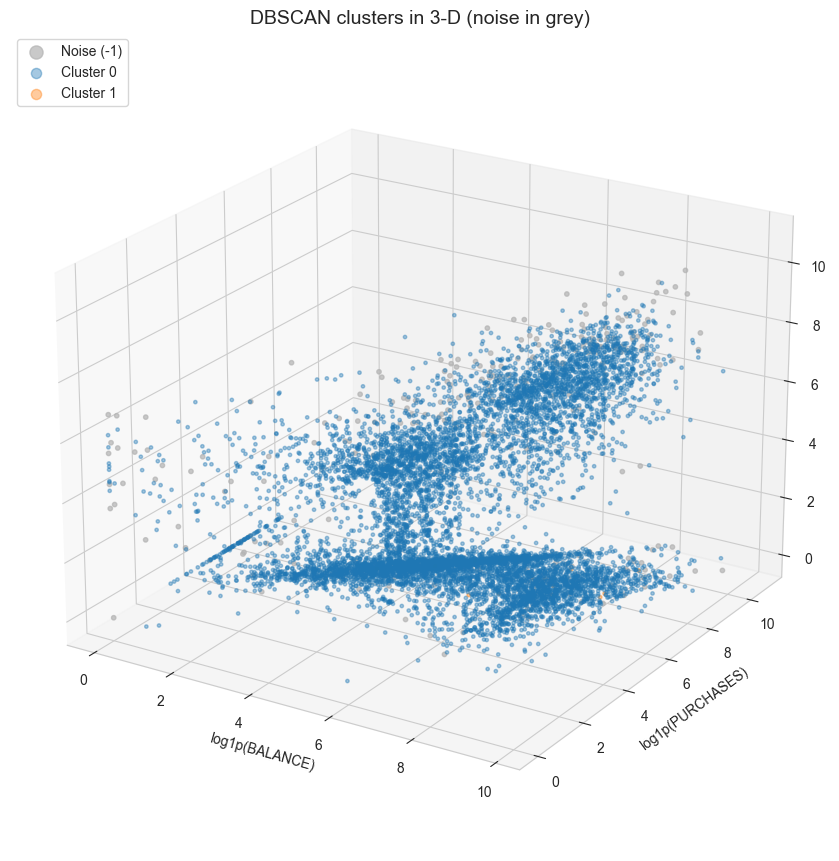

In [64]:
fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection='3d')
for cl in sorted(df_feat['DBSCAN_Cluster'].unique()):
    sub = df_feat[df_feat['DBSCAN_Cluster'] == cl]
    ax.scatter(np.log1p(sub['BALANCE']), np.log1p(sub['PURCHASES']), np.log1p(sub['CASH_ADVANCE']),
               s=10 if cl == -1 else 6, alpha=0.7 if cl == -1 else 0.4, color=pal_db[cl],
               label='Noise (-1)' if cl == -1 else f'Cluster {cl}')
ax.set_xlabel('log1p(BALANCE)'); ax.set_ylabel('log1p(PURCHASES)'); ax.set_zlabel('log1p(CASH_ADVANCE)', labelpad=8)
ax.set_title('DBSCAN clusters in 3-D (noise in grey)', fontsize=14)
ax.view_init(elev=22, azim=-58); ax.legend(markerscale=3, loc='upper left')
fig.subplots_adjust(left=0.0, right=0.86, bottom=0.03, top=0.94)
plt.savefig('images/20_dbscan_3d.png', dpi=130)
plt.show()

In [65]:
db_profile = core.groupby('DBSCAN_Cluster')[profile_cols].mean()
db_profile['Customers'] = core['DBSCAN_Cluster'].value_counts()
db_profile['Share_%'] = (db_profile['Customers'] / len(df_feat) * 100).round(2)
db_profile.sort_values('CREDIT_LIMIT', ascending=False).round(2)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,TENURE,Customers,Share_%
DBSCAN_Cluster,,,,,,,,
1,1425.83,1722.15,0.00,5293.33,0.00,12.00,15,0.17
0,1543.43,961.03,913.87,4462.78,1651.15,11.58,8651,96.66


In [66]:
core.groupby('DBSCAN_Cluster')[extra_cols].mean().round(3)

,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PRC_FULL_PAYMENT,Limit_Usage,Payment_to_Minpayment_Ratio
DBSCAN_Cluster,,,,,
0,0.488,0.128,0.152,0.387,5.783
1,0.939,0.000,0.000,0.255,0.000


### What do the noise customers look like compared with everyone else?

In [67]:
noise_compare = pd.DataFrame({
    'Noise_mean': noise[profile_cols + extra_cols].mean(),
    'Non_noise_mean': core[profile_cols + extra_cols].mean(),
})
noise_compare['Noise / Non-noise'] = noise_compare['Noise_mean'] / noise_compare['Non_noise_mean']
noise_compare.round(3)

,Noise_mean,Non_noise_mean,Noise / Non-noise
BALANCE,2212.974,1543.222,1.434
PURCHASES,2249.837,962.351,2.338
CASH_ADVANCE,3010.572,912.289,3.300
CREDIT_LIMIT,5411.690,4464.217,1.212
PAYMENTS,4322.208,1648.296,2.622
TENURE,9.577,11.581,0.827
PURCHASES_FREQUENCY,0.553,0.488,1.133
CASH_ADVANCE_FREQUENCY,0.363,0.128,2.842
PRC_FULL_PAYMENT,0.203,0.152,1.332
Limit_Usage,0.440,0.387,1.135


In [68]:
# personas for DBSCAN clusters: biggest cluster = mainstream core, others named from their profile
db_personas = {db_profile['Customers'].idxmax(): 'Mainstream Core Cardholders', db_profile['PAYMENTS'].idxmin(): 'Non-Paying Active Spenders'}
db_personas[-1] = 'Extreme / Unusual Accounts (RM review)'
df_feat['DBSCAN_Persona'] = df_feat['DBSCAN_Cluster'].map(db_personas)
df_feat['DBSCAN_Persona'].value_counts().to_frame('customers')

,customers
DBSCAN_Persona,
Mainstream Core Cardholders,8651
Extreme / Unusual Accounts (RM review),284
Non-Paying Active Spenders,15


**Observation:** DBSCAN found one large **Mainstream Core** (8,651 customers, 96.7%) and one tiny cluster of **15 Non-Paying Active Spenders**: they buy often (94% of months) but have **zero payments** and never pay in full. That group looks like a delinquency or fraud risk.

The **284 noise customers (3.2%)** are extreme accounts, and they are not unimportant. Compared with everyone else they have about **3.3x the cash advance, 2.6x the payments, 2.3x the purchases and 4.4x the payment-to-minimum ratio**, and a shorter tenure (9.6 vs 11.6 months). They are ultra-active or unusual cash-heavy accounts that fit no group. For **credit-risk** they should go on a watch-list, and for **marketing** they should be handled by a Relationship Manager, not by an automated campaign.

# 📊 Step 6: Algorithm Comparison & Business Interpretation

## 6.1 Internal metrics comparison

In [69]:
def evaluate_clustering(name, params, labels, data):
    """Silhouette / Davies-Bouldin / Calinski-Harabasz. For DBSCAN the noise points (-1) are excluded from the scores."""
    labels = np.asarray(labels)
    mask = labels != -1
    sizes = pd.Series(labels[mask]).value_counts()
    return {
        'Algorithm': name,
        'Hyperparameters': params,
        'Clusters': int(sizes.shape[0]),
        'Silhouette (higher better)': silhouette_score(data[mask], labels[mask]),
        'Davies-Bouldin (lower better)': davies_bouldin_score(data[mask], labels[mask]),
        'Calinski-Harabasz (higher better)': calinski_harabasz_score(data[mask], labels[mask]),
        'Noise %': (~mask).mean() * 100,
        'Smallest cluster %': sizes.min() / len(labels) * 100,
    }

comparison = pd.DataFrame([
    evaluate_clustering('K-Means', f'k={k_optimal}, init=k-means++, n_init=20', df_feat['KMeans_Cluster'], X),
    evaluate_clustering('Agglomerative', f'n_clusters={n_chosen}, linkage={best_link}', df_feat['Agg_Cluster'], X),
    evaluate_clustering('DBSCAN', f'eps={best_eps}, min_samples={best_ms}', df_feat['DBSCAN_Cluster'], X),
]).set_index('Algorithm')
comparison.round(3)

,Hyperparameters,Clusters,Silhouette (higher better),Davies-Bouldin (lower better),Calinski-Harabasz (higher better),Noise %,Smallest cluster %
Algorithm,,,,,,,
K-Means,"k=4, init=k-means++, n_init=20",4,0.198,1.706,2057.446,0.000,18.413
Agglomerative,"n_clusters=4, linkage=ward",4,0.142,1.999,1594.940,0.000,17.966
DBSCAN,"eps=2.5, min_samples=10",2,0.174,1.127,24.194,3.173,0.168


In [70]:
# rank on the three internal metrics (1 = best)
ranks = pd.DataFrame({
    'Silhouette rank': comparison['Silhouette (higher better)'].rank(ascending=False),
    'Davies-Bouldin rank': comparison['Davies-Bouldin (lower better)'].rank(ascending=True),
    'Calinski-Harabasz rank': comparison['Calinski-Harabasz (higher better)'].rank(ascending=False),
})
ranks['Average rank'] = ranks.mean(axis=1)
ranks.sort_values('Average rank')

,Silhouette rank,Davies-Bouldin rank,Calinski-Harabasz rank,Average rank
Algorithm,,,,
K-Means,1.0,2.0,1.0,1.333333
DBSCAN,2.0,1.0,3.0,2.000000
Agglomerative,3.0,3.0,2.0,2.666667


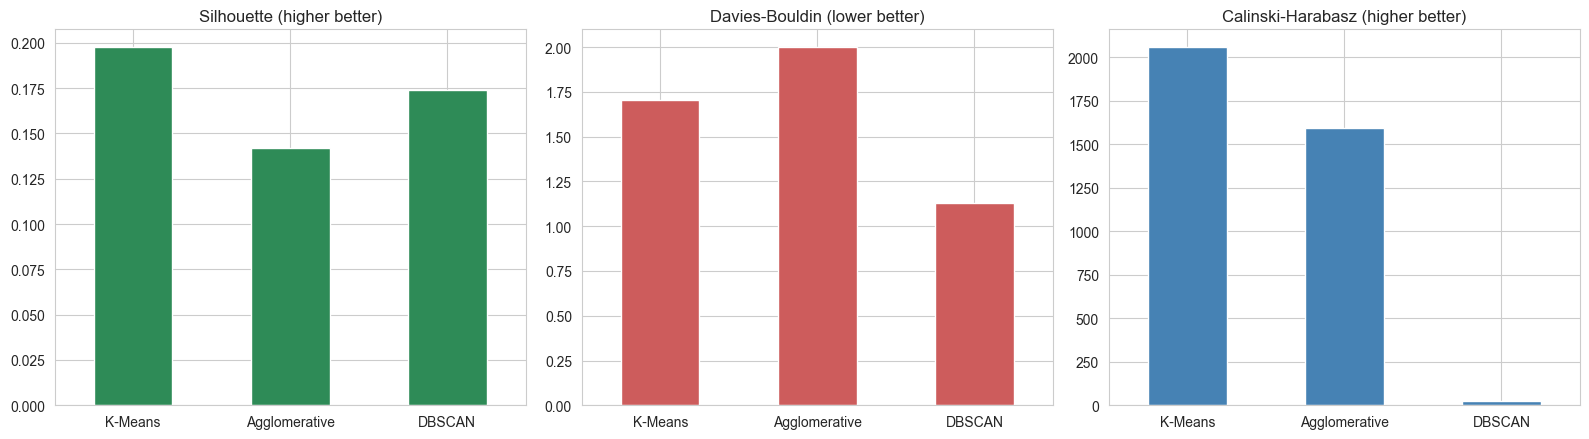

In [71]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, col, colr in zip(ax, ['Silhouette (higher better)', 'Davies-Bouldin (lower better)', 'Calinski-Harabasz (higher better)'],
                        ['seagreen', 'indianred', 'steelblue']):
    comparison[col].plot(kind='bar', ax=a, color=colr, rot=0)
    a.set_title(col); a.set_xlabel('')
plt.tight_layout()
plt.savefig('images/21_metrics_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

**Observation:** K-Means ranks first on Silhouette (0.198) and Calinski-Harabasz (2,057), and DBSCAN ranks first on Davies-Bouldin (1.13), but that is because it has only two clusters and one of them holds 96.7% of everyone, plus its Calinski-Harabasz is only 24. Agglomerative Ward ranks last on Silhouette and Davies-Bouldin. **Ranking by average rank: 1) K-Means (1.33), 2) DBSCAN (2.0), 3) Agglomerative (2.67).** K-Means gives the most well-separated, compact **and** balanced clusters (smallest cluster is 18.4%). This matches my business intuition: the four K-Means personas are easy to explain. One honest point: a Silhouette of about 0.2 is low in absolute terms, so the segments overlap and should be treated as soft segments.

## 6.2 Cluster stability check for K-Means

In [72]:
seeds = [0, 7, 21, 42, 99]
stab_rows = []
for s in seeds:
    km = KMeans(n_clusters=k_optimal, init='k-means++', n_init=20, max_iter=500, random_state=s).fit(X)
    stab_rows.append([s, silhouette_score(X, km.labels_), km.inertia_, adjusted_rand_score(kmeans_final.labels_, km.labels_)])

stability = pd.DataFrame(stab_rows, columns=['random_state', 'Silhouette', 'Inertia', 'ARI vs seed 42']).set_index('random_state')
stability.round(4)

,Silhouette,Inertia,ARI vs seed 42
random_state,,,
0,0.1973,111215.3934,0.9840
7,0.1973,111215.4436,0.9829
21,0.1976,111215.7367,0.9769
42,0.1975,111216.0313,1.0000
99,0.1974,111215.4057,0.9826


In [73]:
print(f"Silhouette across 5 runs: {stability['Silhouette'].mean():.4f} +/- {stability['Silhouette'].std():.4f}")
print(f"Inertia across 5 runs   : {stability['Inertia'].mean():.1f} +/- {stability['Inertia'].std():.1f}")
print(f"Mean ARI vs seed 42     : {stability['ARI vs seed 42'].mean():.3f}")

Silhouette across 5 runs: 0.1974 +/- 0.0001
Inertia across 5 runs   : 111215.6 +/- 0.3
Mean ARI vs seed 42     : 0.985


**Observation:** K-Means is **very stable**. Silhouette over 5 seeds is 0.1974 +/- 0.0001 and the inertia is 111,215.6 +/- 0.3. The Adjusted Rand Index against the seed-42 run is 0.977 to 0.984, so almost every customer lands in the same cluster on every run. The result does not depend on the random seed.

## 6.3 Business recommendation

### To: Head of Cards & Payments &nbsp;|&nbsp; From: Junior Data Scientist, Analytics Team
### Subject: Cardholder segmentation — recommendation

**1. Which algorithm to deploy: K-Means (k = 4).** It has the best Silhouette (0.198) and Calinski-Harabasz (2,057) of the three, it produces balanced segments (18% to 28% of customers each), and it is very stable (Silhouette 0.1974 +/- 0.0001 over 5 seeds). It can also score a new customer instantly with a saved scaler and model (`predict_segment()`), which is what the Relationship Managers need. Agglomerative Ward gives similar but slightly worse groups and cannot score new customers without re-running. DBSCAN sees the base as one dense blob, so I do not use it for segmentation. **I do recommend running DBSCAN alongside it as a risk watch-list**, because its 284 noise accounts (3.2% of customers) have about 3.3x the cash advance and 4.4x the payment-to-minimum ratio of normal customers, and a 15-customer group buys but never pays.

**2. Four cardholder segments**

| Segment | Size | One-line description | Action |
|---|---|---|---|
| **Premium Transactors** | 18.4% | Spend the most (about 3,284), highest limit, buy in ~91% of months, low limit usage, often pay in full. | Offer a **premium rewards / co-branded card upgrade with a higher credit limit** and cashback on their top categories. They generate fees and interchange, so keep them happy and avoid attrition. |
| **Revolvers** | 27.1% | Big balance (2,546), 67% limit usage, pay only ~2x the minimum and almost never in full. | Offer a **balance-transfer EMI plan** or EMI conversion of large purchases. They generate the most interest income, so also monitor them for stress. |
| **Cash-Advance Reliant** | 26.4% | Almost no purchases (22) but heavy cash advance (2,161) and a high balance; they use the card as a loan. | Offer a cheaper **pre-approved personal loan or cash line** instead of costly cash advances, with credit-risk monitoring and financial-wellness nudges. |
| **Low-Activity Light Users** | 28.1% | Balance about 113, 5% limit usage, low spending and payments. Nearly dormant. | Send a **reactivation offer with a waived annual fee** and a small spend-and-earn cashback to build the habit before they churn. |

**3. What extra data would improve the next iteration?** (a) Merchant category and transaction-level data to see *what* customers buy (travel, fuel, groceries, online); (b) repayment history and days-past-due, and bureau scores, to separate risky revolvers from safe ones; (c) income, age, city and employment; (d) other products held with the bank (savings account, loans, salary account); (e) a monthly time series instead of one 12-month snapshot, to catch customers who are changing behaviour; (f) real revenue per customer (interest, fees, interchange) and churn labels, so a semi-supervised model can be checked against actual outcomes.

**Caveat:** A Silhouette of about 0.2 means the segments overlap, so treat them as soft, behaviour-based groups and review borderline customers before large campaigns.

# 🚀 Step 7: Pipeline, Deployment & Submission

## 7.1 Save the final clustering pipeline

In [74]:
best_model = kmeans_final          # K-Means is the algorithm I recommend for deployment (see 6.3)
joblib.dump(scaler, 'cc_scaler.pkl')
joblib.dump(best_model, 'cc_segmentation_model.pkl')

# small helper file with everything predict_segment() needs besides the scaler + model
joblib.dump({'feature_cols': feature_cols, 'cap_cols': cap_cols, 'cap_thresholds': cap_thresholds,
             'medians': medians, 'personas': {int(k): v for k, v in km_personas.items()}},
            'cc_preprocessing.pkl')
print(sorted(f for f in os.listdir('.') if f.endswith('.pkl')))

['cc_preprocessing.pkl', 'cc_scaler.pkl', 'cc_segmentation_model.pkl']


## 7.2 `predict_segment()` — raw values in, cluster + persona out

In [75]:
def predict_segment(new_customers):
    """new_customers: dict / list of dicts / DataFrame holding the 17 RAW columns (no CUST_ID).
    Repeats the exact training pipeline: engineer -> cap -> log1p -> scale -> K-Means -> persona."""
    sc = joblib.load('cc_scaler.pkl')
    mdl = joblib.load('cc_segmentation_model.pkl')
    cfg = joblib.load('cc_preprocessing.pkl')

    new = pd.DataFrame(new_customers).copy()
    for c, med in cfg['medians'].items():                       # same imputation as training
        new[c] = new[c].fillna(med)

    new['Monthly_Avg_Purchase']        = new['PURCHASES'] / new['TENURE']
    new['Monthly_Avg_Cash_Advance']    = new['CASH_ADVANCE'] / new['TENURE']
    new['Limit_Usage']                 = (new['BALANCE'] / new['CREDIT_LIMIT'].replace(0, np.nan)).fillna(0)
    new['Payment_to_Minpayment_Ratio'] = new['PAYMENTS'] / (new['MINIMUM_PAYMENTS'] + 1)

    for c in cfg['cap_cols']:                                   # cap with the TRAINING thresholds
        new[c] = new[c].clip(upper=cfg['cap_thresholds'][c])
    new[cfg['cap_cols']] = np.log1p(new[cfg['cap_cols']])

    scaled = sc.transform(new[cfg['feature_cols']])
    labels = mdl.predict(scaled)
    return pd.DataFrame({'Cluster': labels, 'Persona': [cfg['personas'][int(l)] for l in labels]}, index=new.index)

### Sanity check: the function must reproduce the training labels

In [76]:
check_labels = predict_segment(df.iloc[:500])
print('Match with training K-Means labels on 500 customers: {:.1f}%'.format((check_labels['Cluster'].values == df_feat['KMeans_Cluster'].iloc[:500].values).mean() * 100))

Match with training K-Means labels on 500 customers: 100.0%


### Test on 5 hypothetical new cardholders

In [77]:
new_customers = pd.DataFrame([
    # BALANCE, BAL_FREQ, PURCH, ONEOFF, INSTALL, CASH_ADV, PURCH_FREQ, ONEOFF_FREQ, INST_FREQ, CASH_FREQ, CASH_TRX, PURCH_TRX, LIMIT, PAYMENTS, MIN_PAY, PRC_FULL, TENURE
    [1800, 1.0, 9000, 5000, 4000,    0, 1.0, 0.8, 0.7, 0.0,  0, 60, 15000, 9500,  800, 0.8, 12],   # customer A
    [4200, 1.0, 1500,  900,  600,  500, 0.6, 0.3, 0.4, 0.1,  2, 20,  9000,  900,  850, 0.0, 12],   # customer B
    [3800, 0.9,    0,    0,    0, 7000, 0.0, 0.0, 0.0, 0.6, 18,  0,  8000, 2500, 1200, 0.0, 12],   # customer C
    [  60, 0.5,  300,  300,    0,    0, 0.1, 0.1, 0.0, 0.0,  0,  3,  3000,  250,  120, 0.3, 12],   # customer D
    [ 400, 0.6,  800,  800,    0,    0, 0.5, 0.5, 0.0, 0.0,  0,  6,  5000,  500,  200, 0.5,  6],   # customer E
], columns=df.columns, index=list('ABCDE'))

print('INPUTS'); display(new_customers)
print('PREDICTIONS'); display(predict_segment(new_customers))

INPUTS


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
A,1800,1.0,9000,5000,4000,0,1.0,0.8,0.7,0.0,0,60,15000,9500,800,0.8,12
B,4200,1.0,1500,900,600,500,0.6,0.3,0.4,0.1,2,20,9000,900,850,0.0,12
C,3800,0.9,0,0,0,7000,0.0,0.0,0.0,0.6,18,0,8000,2500,1200,0.0,12
D,60,0.5,300,300,0,0,0.1,0.1,0.0,0.0,0,3,3000,250,120,0.3,12
E,400,0.6,800,800,0,0,0.5,0.5,0.0,0.0,0,6,5000,500,200,0.5,6


PREDICTIONS


,Cluster,Persona
A,3,Premium Transactors
B,0,Revolvers
C,2,Cash-Advance Reliant
D,1,Low-Activity Light Users
E,1,Low-Activity Light Users


**Observation:** The function reproduced the training labels for 100% of the first 500 customers, so the saved pipeline (scaler + caps + log + model) is consistent. On the 5 hypothetical customers it gave sensible answers: A (big spender who pays in full) -> Premium Transactors, B (large balance, pays near the minimum) -> Revolvers, C (7,000 cash advance and no purchases) -> Cash-Advance Reliant, D (tiny balance and little spending) -> Low-Activity Light Users. Customer E (a new 6-month customer with moderate spending) also went to Low-Activity Light Users. There is no separate 'New-to-Card' segment because 85% of customers have 12 months of tenure, so tenure is not a strong differentiator in this data.

## 7.3 Save the labelled customer table

In [78]:
df_feat.assign(CUST_ID=cust_id).to_csv('customer_segments.csv', index=False)
print('Saved customer_segments.csv ->', df_feat.shape[0], 'rows')
print('Files in the project folder:', sorted(f for f in os.listdir('.') if not f.startswith('.')))

Saved customer_segments.csv -> 8950 rows
Files in the project folder: ['CreditCardSegmentation_UnsupervisedLearning.ipynb', 'cc_preprocessing.pkl', 'cc_scaler.pkl', 'cc_segmentation_model.pkl', 'customer_segments.csv', 'images']


---
**End of notebook.** Files produced: `cc_scaler.pkl`, `cc_segmentation_model.pkl`, `cc_preprocessing.pkl`, `customer_segments.csv`, `images/`.